# Urban Heat Island Challenge — Introduction

Urban Heat Islands (UHI) have significant environmental and societal impacts, including increased energy consumption, reduced air quality, and heightened health risks due to extreme heat exposure. These localized temperature increases are primarily driven by urbanization factors such as dense infrastructure, limited vegetation, and heat-retaining surfaces, making it critical to understand and predict their spatial distribution. To address this challenge, this analysis leverages geospatial and remote sensing data to model and classify UHI intensity across different urban environments.
Spectral band data from Sentinel-2 satellite imagery was utilized as a key input, where GeoTIFF files were generated and processed to extract relevant indices such as vegetation and built-up indicators. These derived features, combined with spatial data, were used to train multiple machine learning models including K-Nearest Neighbours (KNN), XGBoost, Multi-Layer Perceptron (MLP), LightGBM, Residual MLP, and Random Forest. The goal of the analysis was to develop robust predictive models capable of classifying UHI intensity into Low, Medium, and High categories.
The study focuses on three geographically distinct regions: Santiago (Chile), Rio de Janeiro (Brazil), and Freetown (Sierra Leone), allowing for both model training and generalization across diverse urban settings. By comparing model performance and leveraging rich geospatial features, the analysis aims to identify the most effective approaches for accurately predicting UHI classes and supporting data-driven urban planning decisions


---
## Setup

### Installations

In [77]:
# Package Installations
!pip install torch

### Imports

In [78]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Standard library
import os
from collections import Counter

# Data manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import QuantileTransformer, LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier, BallTree
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier


from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, classification_report, f1_score
)
from xgboost import XGBClassifier

# Neural network — PyTorch
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    from torch.optim.swa_utils import AveragedModel, SWALR
    TORCH_OK = True
    print(f'PyTorch {torch.__version__} available')
except ImportError:
    TORCH_OK = False
    print('PyTorch not installed — neural net section will be skipped')
    print(' Install with: pip install torch')

print("Setup complete.")

PyTorch 2.11.0+cpu available
Setup complete.


### Configuration

In [79]:
# File paths
PATHS = {
    'chile_combined':   'chile_combined.csv',
    'brazil_combined':  'Brazil_combined.csv',
    'sierra_combined':  'sierra_combined.csv',
    'submission':       'predicted_freetown.csv',
    'freetown_labeled': 'freetown_labeled_enhanced.csv'
}

# Label encoding
CLASS_MAP = {'High': 0, 'Low': 1, 'Medium': 2}
INV_MAP   = {0: 'High', 1: 'Low', 2: 'Medium'}
CLASSES   = ['High', 'Low', 'Medium']

# Feature sets
SPECTRAL_COLS = [
    'Longitude', 'Latitude', 'UHI_Class',
    'median_NDVI', 'median_NDBI', 'median_NDWI',
    'NDVI_std', 'NDBI_std', 'NDWI_std',
    'NDMI', 'BSI'
]
BUILDING_COLS = [
    'building_density_100m', 'building_coverage',
    'avg_building_size', 'mean_building_height', 'weighted_height'
]
MODEL_FEATURES = [
    'median_NDVI', 'median_NDBI', 'median_NDWI',
    'NDVI_std', 'NDBI_std', 'NDWI_std',
    'NDMI', 'BSI',
    'building_density_100m', 'building_coverage',
    'mean_building_height', 'weighted_height', 'avg_building_size'
]
RAW_FEATURES = [
    'median_NDVI',
    'median_NDBI',
    'median_NDWI',
    'building_density_100m',   
]
TARGET_LABEL = 'label'

# Constants
RANDOM_STATE     = 42
TEST_SIZE        = 0.30
PSEUDO_ROUNDS    = 3
PSEUDO_THRESHOLD = 0.70
SMOOTH_K         = 7
SMOOTH_THRESHOLD = 0.65
CONF_THRESHOLD_HIGH = 0.55
CONF_THRESHOLD_LOW  = 0.45

# Neural network settings
NN_EPOCHS      = 150
NN_BATCH_SIZE  = 256
NN_LR          = 0.001
NN_DROPOUT     = 0.3
NN_HIDDEN      = [256, 128, 64]  # layer sizes
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


print("Configuration loaded.")

Configuration loaded.


---
## Load Data

In [80]:
# Loadinging combined datasets
chile_combined  = pd.read_csv(PATHS['chile_combined'])
brazil_combined = pd.read_csv(PATHS['brazil_combined'])
sierra_combined = pd.read_csv(PATHS['sierra_combined'])
freetown_labeled = pd.read_csv(PATHS['freetown_labeled'])

print("Data loaded.")

# Class distribution summary
header = f"{'City':<12} {'Rows':>8}  {'High':>8}  {'Low':>8}  {'Medium':>8}"
print(f"\n{header}")
print("-" * 50)

for name, df in [('Chile', chile_combined), ('Brazil', brazil_combined)]:

    vcounts = df['UHI_Class'].value_counts()
    n_rows  = len(df)
    n_high  = vcounts.get('High',   0)
    n_low   = vcounts.get('Low',    0)
    n_med   = vcounts.get('Medium', 0)

    print(f"{name:<12} {n_rows:>8,}  {n_high:>8,}  {n_low:>8,}  {n_med:>8,}")

print("Freetown Shape: ", sierra_combined.shape)

Data loaded.

City             Rows      High       Low    Medium
--------------------------------------------------
Chile          21,662     5,317     5,529    10,816
Brazil         28,488    12,748    10,591     5,149
Freetown Shape:  (14105, 16)


---
## Exploratory Data Analysis

We explore each region before modeling to understand:
- Class distributions (how balanced are High / Medium / Low?)
- Feature value ranges (are Freetown values in the same range as training data?)
- Key differences between cities that will cause domain shift

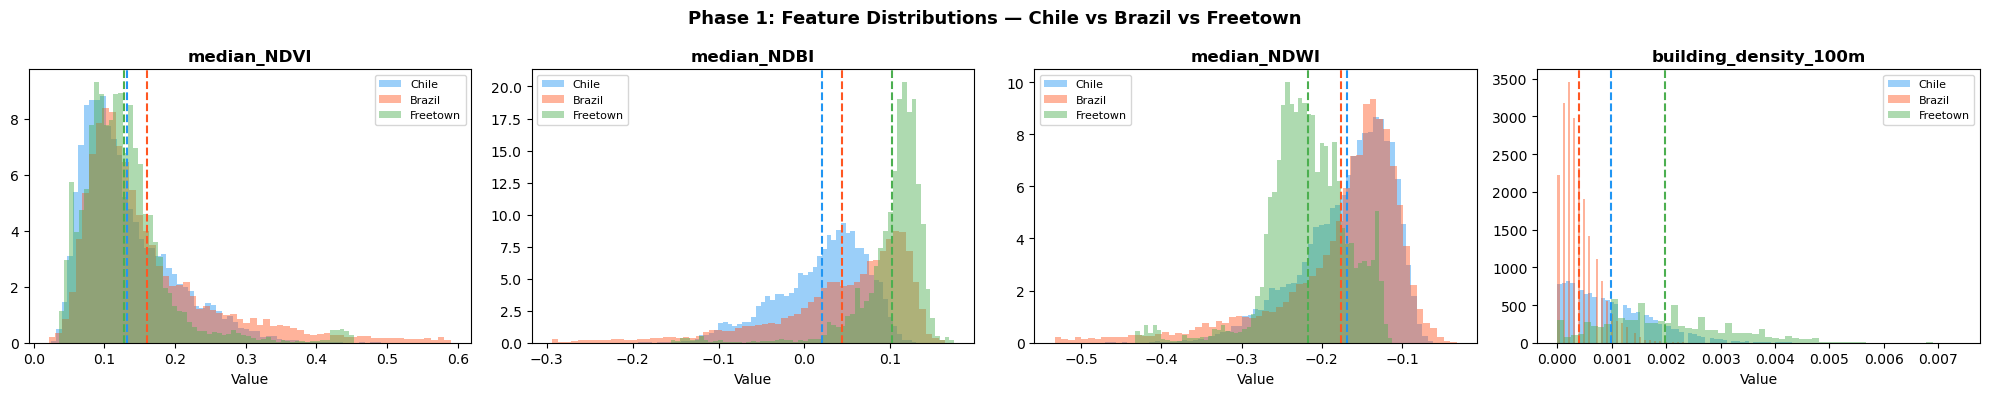

In [81]:
# ── Phase 1: Feature distribution comparison ──────────────────

# Only plot features that exist in all three datasets
plot_features = [f for f in RAW_FEATURES if f in sierra_combined.columns and f in chile_combined.columns and f in brazil_combined.columns]

n_feats = len(plot_features)
fig, axes = plt.subplots(1, n_feats, figsize=(5 * n_feats, 4))
if n_feats == 1:
    axes = [axes]
fig.suptitle('Phase 1: Feature Distributions — Chile vs Brazil vs Freetown', 
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes, plot_features):
    for label, df, color in [
        ('Chile',    chile_combined,   '#2196F3'),
        ('Brazil',   brazil_combined,  '#FF5722'),
        ('Freetown', sierra_combined, '#4CAF50'),
    ]:
        if feat in df.columns:
            ax.hist(df[feat].dropna(), bins=60, alpha=0.45, color=color, 
                    label=label, density=True)
            ax.axvline(df[feat].mean(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlabel('Value')

plt.tight_layout()
plt.savefig('phase1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Functions & Utilities

All helper functions are defined here in one place.  
Models depend on these functions.

| Function | Purpose |
|----------|---------|
| `within_region_rank` | Normalise features by their own city's distribution |
| `run_model_pipeline` | Train + evaluate any model on a single city dataset |
| `predict_freetown` | Generate Freetown predictions from any sklearn model |
| `freetown_full_pipeline` | Full Freetown pipeline: train → pseudo-label → predict → smooth |
| `spatial_smooth` | Fix low-confidence predictions using geographic neighbours |
| `count_heat_jumps` | Count physically impossible Low↔High transitions |
| `ResidualBlock / ResidualMLP` | PyTorch neural network architecture |
| `prepare_training_data` | Combine SA + Freetown labels + build shared scaler |
| `create_dataloaders` | Build PyTorch train/val DataLoaders |
| `train_residual_mlp` | Train NN with early stopping |
| `init_residual_mlp` | Initialise fresh NN model |
| `predict_nn_freetown` | Get predictions from trained NN |
| `residual_mlp_pipeline` | Full NN pipeline: train → pseudo-label → predict → smooth |
| `submission_util` | Save submission CSV from NN model |

### Feature normalisation

In [82]:
def within_region_rank(df, features, n_quantiles=500):
    """
    Normalise each region by its own distribution.
    Each value → percentile rank [0,1] within its own city.
    Prevents absolute pixel value differences between cities from confusing the model.
    """
    df_out = df.copy()
    valid  = [f for f in features if f in df.columns]
    qt = QuantileTransformer(
        n_quantiles=min(n_quantiles, len(df)),
        output_distribution='uniform',
        random_state=42
    )
    df_out[valid] = qt.fit_transform(df[valid].fillna(df[valid].median()))
    return df_out, qt

chile_r,  _ = within_region_rank(chile_combined,  MODEL_FEATURES)
brazil_r, _ = within_region_rank(brazil_combined, MODEL_FEATURES)
sierra_r, _ = within_region_rank(sierra_combined, MODEL_FEATURES)
freetown_r, _ = within_region_rank(freetown_labeled, MODEL_FEATURES)

# Encode labels
chile_combined['label']  = chile_combined['UHI_Class'].map(CLASS_MAP)
brazil_combined['label'] = brazil_combined['UHI_Class'].map(CLASS_MAP)

print(' Within-region rank normalisation complete')

 Within-region rank normalisation complete


### Model evaluation pipeline

In [83]:
# Function to run the full pipeline for a given model and dataset
def run_model_pipeline(
    model,
    dataset
    ):
    """
    End-to-end pipeline:
    - Remove duplicates
    - Scale features
    - Train/test split
    - Train model
    - Evaluate (Accuracy + F1 + gap)
    
    Returns:
        dict with metrics (for model comparison)
    """

    #  Remove duplicates

    train_df = dataset.copy()

    dup_cols = [f for f in MODEL_FEATURES if f in train_df.columns]
    before = len(train_df)

    train_df = train_df.drop_duplicates(subset=dup_cols).reset_index(drop=True)

    removed = before - len(train_df)
    print(f"Duplicates removed: {removed:,} ({before:,} → {len(train_df):,} rows)")


    #  Split features/labels

    X = train_df[MODEL_FEATURES].values
    y = train_df[TARGET_LABEL].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )

    print(f"\nTraining set : {X_train.shape[0]:,} rows × {X_train.shape[1]} features")
    print(f"Test set     : {X_test.shape[0]:,} rows")

  
    # Scaling
   
   
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

  
    # Train model

    model.fit(X_train_scaled, y_train)

  
    #  Predictions

    train_preds = model.predict(X_train_scaled)
    test_preds  = model.predict(X_test_scaled)

    #  Metrics

    train_acc = accuracy_score(y_train, train_preds)
    test_acc  = accuracy_score(y_test,  test_preds)

    train_f1 = f1_score(y_train, train_preds, average='macro')
    test_f1  = f1_score(y_test,  test_preds,  average='macro')

    gap = train_f1 - test_f1

    # Output

    print(f"\n{'='*50}")
    print(f"MODEL: {model.__class__.__name__}")
    print(f"{'='*50}")
    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Test Accuracy  : {test_acc:.4f}")
    print(f"Train F1       : {train_f1:.4f}")
    print(f"Test F1        : {test_f1:.4f}")
    print(f"F1 Gap         : {gap:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test, test_preds,
        target_names=['High', 'Low', 'Medium']
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_test, test_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'{model.__class__.__name__} — Confusion Matrix')
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    # Return metrics

    return {
        "model": model.__class__.__name__,
        "train_f1": train_f1,
        "test_f1": test_f1,
        "gap": gap,
        "train_acc": train_acc,
        "test_acc": test_acc
    }

### Spatial smoothing & heat jump detection

In [84]:
# Spatial smoothing function
def spatial_smooth(df, pred_col, conf_col, k=SMOOTH_K, conf_threshold=SMOOTH_THRESHOLD):
    """
    Replace low-confidence predictions with the majority vote from
    K nearest geographic neighbours (haversine distance).
    Only modifies predictions below the confidence threshold.

    Parameters
    ----------
    df             : pd.DataFrame  Must have Latitude, Longitude columns
    pred_col       : str           Column containing string predictions
    conf_col       : str           Column containing confidence scores [0, 1]
    k              : int           Number of neighbours to consider
    conf_threshold : float         Only smooth points below this confidence
    """
    coords_rad    = np.radians(df[['Latitude', 'Longitude']].values)
    tree          = BallTree(coords_rad, metric='haversine')
    preds_smooth  = df[pred_col].copy().values
    low_conf_mask = df[conf_col].values < conf_threshold

    # Query all neighbours at once — faster than point-by-point
    _, indices = tree.query(coords_rad, k=k + 1)   # +1 to exclude self

    n_changed = 0
    for i in np.where(low_conf_mask)[0]:
        neighbours    = preds_smooth[indices[i][1:]]
        majority_vote = Counter(neighbours).most_common(1)[0][0]

        if majority_vote != preds_smooth[i]:
            preds_smooth[i] = majority_vote
            n_changed      += 1

    print(f"  Eligible (conf < {conf_threshold}): {low_conf_mask.sum():,}")
    print(f"  Changed:  {n_changed:,} ({n_changed / len(df) * 100:.1f}% of all points)")

    return preds_smooth

In [85]:
# Heat jump counting function
def count_heat_jumps(df, pred_col, k=5):
    """
    Count physically impossible Low↔High transitions.
    A point predicted as Low surrounded entirely by High neighbours
    (or vice versa) is a spatial contradiction. Lower = better.
    """
    coords_rad = np.radians(df[['Latitude', 'Longitude']].values)
    tree       = BallTree(coords_rad, metric='haversine')
    _, indices = tree.query(coords_rad, k=k + 1)
    preds      = df[pred_col].values
    n_jump     = 0

    for i in range(len(preds)):
        neighbours = [preds[j] for j in indices[i][1:]]

        if preds[i] == 'Low'  and all(n == 'High' for n in neighbours):
            n_jump += 1
        if preds[i] == 'High' and all(n == 'Low'  for n in neighbours):
            n_jump += 1

    return n_jump


### Freetown prediction utilities

In [86]:
# Freetown prediction pipeline
def predict_freetown(model, X_ft, coords_df, model_name='Model'):
    """
    Shared Freetown prediction pipeline — works with any sklearn-compatible model.

    Steps
    -----
    1. Get predicted probabilities from model
    2. Apply threshold adjustment (reduces High bias for uncertain points)
    3. Apply spatial smoothing (enforces Low → Medium → High transitions)
    4. Report heat jumps before and after smoothing

    Parameters
    ----------
    model      : trained sklearn model with predict_proba
    X_ft       : np.ndarray   Freetown feature matrix
    coords_df  : pd.DataFrame Must have Longitude and Latitude columns
    model_name : str          Label used in printed output

    Returns
    -------
    pd.DataFrame with columns: Longitude, Latitude, pred_raw, confidence, pred_smooth
    """
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")

    # Predicted probabilities
    proba      = model.predict_proba(X_ft)
    confidence = proba.max(axis=1)
    classes    = list(model.classes_)
    high_idx   = classes.index(0)   # 0 = High in CLASS_MAP
    low_idx    = classes.index(1)   # 1 = Low  in CLASS_MAP

    # Threshold adjustment
    preds_raw = []
    for p in proba:
        if p[high_idx] >= CONF_THRESHOLD_HIGH:
            preds_raw.append('High')
        elif p[low_idx] >= CONF_THRESHOLD_LOW:
            preds_raw.append('Low')
        else:
            preds_raw.append('Medium')

    # Build prediction dataframe
    pred_df = coords_df.copy()
    pred_df['pred_raw']   = np.array(preds_raw)
    pred_df['confidence'] = confidence

    print(f"\nRaw predictions:")
    print(pred_df['pred_raw'].value_counts().to_string())
    print(f"Mean confidence: {confidence.mean():.3f}")

    # Spatial smoothing
    print(f"\nApplying spatial smoothing...")
    pred_df['pred_smooth'] = spatial_smooth(
        pred_df, 'pred_raw', 'confidence',
        k=SMOOTH_K,
        conf_threshold=SMOOTH_THRESHOLD
    )

    # Heat jump analysis
    jumps_before = count_heat_jumps(pred_df, 'pred_raw')
    jumps_after  = count_heat_jumps(pred_df, 'pred_smooth')
    reduction    = jumps_before - jumps_after

    print(f"\nHeat jumps (Low↔High impossible transitions):")
    print(f"  Before: {jumps_before:,}")
    print(f"  After:  {jumps_after:,}")
    print(f"  Reduced by {reduction:,} ({reduction / max(jumps_before, 1) * 100:.1f}%)")

    print(f"\nFinal distribution:")
    print(f"  {'Class':<10} {'Raw':>8} {'Smoothed':>10}")
    print("  " + "-" * 30)
    for cls in ['High', 'Low', 'Medium']:
        n_raw    = (pred_df['pred_raw']    == cls).sum()
        n_smooth = (pred_df['pred_smooth'] == cls).sum()
        print(f"  {cls:<10} {n_raw:>8,} {n_smooth:>10,}")

    return pred_df


In [87]:
def freetown_full_pipeline(
    model,
    train_df,
    freetown_df,
    feature_cols= MODEL_FEATURES,
    label_col=TARGET_LABEL,
    model_name="Model",
    filename=PATHS['submission'],
    generate_submission =True,
):
    """
    Full pipeline:
    - Train base model
    - Pseudo-labeling
    - Retrain model
    - Evaluate
    - Predict Freetown
    - Spatial smoothing
    - Save submission
    """



    print(f"\n{'='*60}")
    print(f" RUNNING PIPELINE: {model_name}")
    print(f"{'='*60}")

    #  Prepare training data

    train_df = train_df.copy()

    train_df = train_df.drop_duplicates(subset=feature_cols).reset_index(drop=True)

    X = train_df[feature_cols].values
    y = train_df[label_col].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )

    # Scale
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # Freetown features
    X_ft = scaler.transform(freetown_df[feature_cols].values)
    coords_df = freetown_df[['Longitude', 'Latitude']]

    
    # Train base model

    model.fit(X_train, y_train)

    base_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"\nBase Accuracy: {base_acc:.4f}")

  
    # Pseudo-labeling
   
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    X_aug = X_train.copy()
    y_aug = y_train.copy()

    print(f"\nPseudo-labelling: {PSEUDO_ROUNDS} rounds")

    for r in range(PSEUDO_ROUNDS):

        model_pl = RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=42
        )

        model_pl.fit(X_aug, y_aug)

        probs = model_pl.predict_proba(X_ft)
        preds = model_pl.predict(X_ft)
        conf  = probs.max(axis=1)

        mask = conf >= PSEUDO_THRESHOLD

        if mask.sum() < 100:
            mask = conf >= 0.60
            print(f"  Round {r+1}: lowered threshold")

        X_aug = np.vstack([X_aug, X_ft[mask]])
        y_aug = np.concatenate([y_aug, preds[mask]])

        cv_f1 = cross_val_score(
            model_pl, X_aug, y_aug,
            cv=cv,
            scoring='f1_macro'
        ).mean()

        print(f"  Round {r+1}: +{mask.sum()} samples | CV F1={cv_f1:.4f}")

    print(f"\nAugmented size: {len(y_train)} → {len(y_aug)}")

    
    # Retrain final model
   
    model.fit(X_aug, y_aug)

    new_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"\nAfter pseudo-labeling accuracy: {new_acc:.4f}")
    print(f"Change: {new_acc - base_acc:.4f}")


    if generate_submission:

        # Predict Freetown

        pred_df = predict_freetown(
            model,
            X_ft,
            coords_df,
            model_name=model_name
        )

    
        # Save submission
    
        submission_df = pd.DataFrame({
            'Longitude': pred_df['Longitude'],
            'Latitude': pred_df['Latitude'],
            'UHI_Class': pred_df['pred_smooth']
        })

        
        submission_df.to_csv(filename, index=False)

        print(f"\n Submission saved: {filename}")
        print(submission_df['UHI_Class'].value_counts())

        return submission_df
    else:
        return None

### Neural network architecture

The **Residual MLP** uses skip connections so raw feature values are preserved through all layers.  
Architecture: Input(13) → Block(256) → Block(128) → Block(64) → Output(3 classes)

In [88]:
if TORCH_OK:
    # Network definition 
    class ResidualBlock(nn.Module):
        """One residual block: two linear layers with a skip connection."""
        def __init__(self, in_dim, out_dim, dropout_rate=0.3):
            super().__init__()
            self.linear1  = nn.Linear(in_dim, out_dim)
            self.linear2  = nn.Linear(out_dim, out_dim)
            self.bn1      = nn.BatchNorm1d(out_dim)
            self.bn2      = nn.BatchNorm1d(out_dim)
            self.dropout  = nn.Dropout(dropout_rate)
            self.relu     = nn.ReLU()
            # Project input dimension if different from output
            self.skip     = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        
        def forward(self, x):
            skip = self.skip(x)
            out  = self.relu(self.bn1(self.linear1(x)))
            out  = self.dropout(out)
            out  = self.bn2(self.linear2(out))
            return self.relu(out + skip)
    
    class ResidualMLP(nn.Module):
        """
        Residual MLP for tabular UHI classification.
        
        Architecture:
          Input → Block(13→256) → Block(256→128) → Block(128→64) → Output(64→3)
          Each block has a skip connection preserving input features.
        """
        def __init__(self, input_dim, hidden_dims, n_classes, dropout_rate=0.3):
            super().__init__()
            
            layers = []
            in_dim = input_dim
            for hidden_dim in hidden_dims:
                layers.append(ResidualBlock(in_dim, hidden_dim, dropout_rate))
                in_dim = hidden_dim
            
            self.blocks    = nn.Sequential(*layers)
            self.output    = nn.Linear(in_dim, n_classes)
            self.dropout   = nn.Dropout(dropout_rate)
        
        def forward(self, x):
            x = self.blocks(x)
            x = self.dropout(x)
            return self.output(x) 
    
    print(' ResidualMLP architecture defined')
    print(f'   Input: {len(MODEL_FEATURES)} features')
    print(f'   Layers: {len(MODEL_FEATURES)} → {" → ".join(str(h) for h in NN_HIDDEN)} → 3 classes')
else:
    print('  Skipping neural network (PyTorch not available)')

    

 ResidualMLP architecture defined
   Input: 13 features
   Layers: 13 → 256 → 128 → 64 → 3 classes


###  Neural network training utilities

In [89]:
def prepare_training_data(chile_r, brazil_r, freetown_r, features, sierra_r=None):
    """
    Combine datasets + create labels + weights + scale features.

    CHANGE: Added StandardScaler fitted on SA + Freetown + Sierra combined.
    Previously returned raw unscaled X — the NN was training on raw values
    while sklearn models trained on scaled values. Now all models see the
    same scaled feature space.

    Also accepts sierra_r so the scaler includes unlabeled Freetown data
    ('chip sierra' trick — stops Freetown looking like outliers).

    Returns X (scaled), y, w, scaler
    """
    chile_r  = chile_r.copy()
    brazil_r = brazil_r.copy()

    train_sa = pd.concat([chile_r, brazil_r], ignore_index=True)
    train_sa['sample_weight'] = 1.0

    if freetown_r is not None:
        freetown_r = freetown_r.copy()
        freetown_r['sample_weight'] = freetown_r['label_confidence'].clip(0.5, 1.0)
        train_all = pd.concat([train_sa, freetown_r], ignore_index=True)
    else:
        train_all = train_sa

    train_all = train_all.dropna(subset=['label'])

    # Building shared scaler on ALL data including unlabeled Freetown 
    scaler_fit_data = pd.concat([
        chile_r[features],
        brazil_r[features],
        freetown_r[features] if freetown_r is not None else pd.DataFrame(columns=features),
        sierra_r[features] if sierra_r is not None else pd.DataFrame(columns=features),
    ], ignore_index=True).fillna(0)

    scaler = StandardScaler()
    scaler.fit(scaler_fit_data)

    # Scale the training features
    X = scaler.transform(train_all[features].fillna(0))
    y = train_all['label'].astype(int).values
    w = train_all['sample_weight'].values

    return X, y, w, scaler 

In [90]:
def train_residual_mlp(model, train_loader, val_loader, y_all, verbose=True):
    """
    Train model with early stopping + detailed logging
    """
    device = next(model.parameters()).device

    # Class weights
    class_counts = np.bincount(y_all)
    class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)
    class_weights = class_weights / class_weights.sum() * 3

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=NN_LR, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )

    best_f1 = 0
    best_weights = None
    patience = 0

    print("\n Training started")
    print("-" * 60)

    for epoch in range(NN_EPOCHS):

        # TRAIN
        model.train()
        train_loss = 0

        for Xb, yb, _ in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # VALIDATION
        model.eval()
        preds, true = [], []
        val_loss = 0

        with torch.no_grad():
            for Xb, yb, _ in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                logits = model(Xb)

                val_loss += criterion(logits, yb).item()

                preds.extend(logits.argmax(dim=1).cpu().numpy())
                true.extend(yb.cpu().numpy())

        val_loss /= len(val_loader)
        f1 = f1_score(true, preds, average='macro')

        # Scheduler uses validation loss (better than 1-f1)
        scheduler.step(val_loss)

        # PRINT LOGS
        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(
                f"Epoch {epoch+1:3d}/{NN_EPOCHS} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Val F1: {f1:.4f} "
                f"{'← BEST' if f1 > best_f1 else ''}"
            )

        # EARLY STOPPING
        if f1 > best_f1:
            best_f1 = f1
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1

        if patience >= 25:
            print(f"\n⏹ Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_weights)

    print("\n" + "="*60)
    print(f" Training complete | Best F1: {best_f1:.4f}")
    print("="*60)

    return model

In [91]:
def create_dataloaders(X, y, w):
    """
    Train/validation split + PyTorch loaders
    """
    idx_train, idx_val = train_test_split(
        np.arange(len(X)),
        test_size=0.15,
        stratify=y,
        random_state=42
    )

    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    w_t = torch.tensor(w, dtype=torch.float32)

    train_ds = TensorDataset(X_t[idx_train], y_t[idx_train], w_t[idx_train])
    val_ds   = TensorDataset(X_t[idx_val],   y_t[idx_val],   w_t[idx_val])

    train_loader = DataLoader(train_ds, batch_size=NN_BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=NN_BATCH_SIZE)

    return train_loader, val_loader

In [92]:
def init_residual_mlp(input_dim):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = ResidualMLP(
        input_dim=input_dim,
        hidden_dims=NN_HIDDEN,
        n_classes=3,
        dropout_rate=NN_DROPOUT
    ).to(device)

    return model, device

In [93]:
def predict_nn_freetown(model, X_ft, coords_df):
    """
    NN prediction + probabilities
    """
    device = next(model.parameters()).device

    X_t = torch.tensor(X_ft, dtype=torch.float32).to(device)

    with torch.no_grad():
        probs = torch.softmax(model(X_t), dim=1).cpu().numpy()

    confidence = probs.max(axis=1)
    preds = probs.argmax(axis=1)

    pred_labels = [INV_MAP[p] for p in preds]

    pred_df = coords_df.copy()
    pred_df['pred_raw'] = pred_labels
    pred_df['confidence'] = confidence

    return pred_df

In [94]:
def residual_mlp_pipeline(chile_r, brazil_r, sierra_r, freetown_r):
    """
    Residual MLP pipeline for Freetown prediction.

    CHANGES:
    1. prepare_training_data now returns a scaler — use it to scale X_ft
       so the NN sees Freetown in the same feature space as training data.
    2. Added pseudo-labeling rounds (was missing entirely — sklearn pipelines
       had 3 rounds, NN had 0, so results were inconsistent).
    3. Separated model training from submission saving into two clear phases.
    """
    print("\n Running Residual MLP Pipeline")

    # Prepare data (now includes scaling) 
    X, y, w, scaler = prepare_training_data(
        chile_r, brazil_r, freetown_r, MODEL_FEATURES, sierra_r=sierra_r
    )

    X_ft      = scaler.transform(sierra_r[MODEL_FEATURES].fillna(0))
    coords_df = sierra_r[['Longitude', 'Latitude']].reset_index(drop=True)

    # Initial model training 
    train_loader, val_loader = create_dataloaders(X, y, w)
    model, device = init_residual_mlp(len(MODEL_FEATURES))

    print("\nPhase 1: Initial training...")
    model = train_residual_mlp(model, train_loader, val_loader, y)

    # Pseudo-labeling rounds
    print(f"\nPhase 2: Pseudo-labeling ({PSEUDO_ROUNDS} rounds, threshold={PSEUDO_THRESHOLD})...")

    X_aug = X.copy()
    y_aug = y.copy()
    w_aug = w.copy()

    for round_num in range(1, PSEUDO_ROUNDS + 1):
        # Get NN predictions on unlabeled Freetown
        model.eval()
        device = next(model.parameters()).device
        with torch.no_grad():
            X_ft_t = torch.tensor(X_ft, dtype=torch.float32).to(device)
            probs  = torch.softmax(model(X_ft_t), dim=1).cpu().numpy()

        preds = probs.argmax(axis=1)
        conf  = probs.max(axis=1)

        # Accepting high-confidence predictions only
        threshold = PSEUDO_THRESHOLD
        if (conf >= threshold).sum() < 100:
            threshold = 0.60
            print(f"  Round {round_num}: lowered threshold to {threshold}")

        mask = conf >= threshold

        X_aug = np.vstack([X_aug, X_ft[mask]])
        y_aug = np.concatenate([y_aug, preds[mask]])
        w_aug = np.concatenate([w_aug, conf[mask]])  # confidence as sample weight

        # Retrain with augmented data
        tr_loader, va_loader = create_dataloaders(X_aug, y_aug, w_aug)

        # Reinitialise model fresh each round — avoids compounding early errors
        model, device = init_residual_mlp(len(MODEL_FEATURES))
        model = train_residual_mlp(model, tr_loader, va_loader, y_aug)

        print(f"  Round {round_num}: +{mask.sum():,} pseudo-labels | total: {len(y_aug):,}")

    # Final Freetown predictions
    print("\nPhase 3: Generating final predictions...")
    pred_df = predict_nn_freetown(model, X_ft, coords_df)

    # Smoothing points
    pred_df['pred_smooth'] = spatial_smooth(
        pred_df,
        'pred_raw',
        'confidence',
        k=SMOOTH_K,
        conf_threshold=SMOOTH_THRESHOLD
    )

    # Save submission
    submission_df = pd.DataFrame({
        'Longitude': pred_df['Longitude'],
        'Latitude':  pred_df['Latitude'],
        'UHI_Class': pred_df['pred_smooth']
    })

    submission_df.to_csv(PATHS['submission'], index=False)
    print("Submission saved:", PATHS['submission'])
    print(submission_df['UHI_Class'].value_counts().to_string())

    return submission_df, model

In [95]:
def submission_util(
    model,
    scaler,
    sierra_r,
    filename=PATHS['submission']
):
    """
    Utility function to generate and save submission from a trained NN model.
    This allows us to separate the training phase from the submission generation
    phase, which is useful for testing different smoothing parameters or if we
    want to generate a new submission without retraining.

    Parameters
    ----------
    model      : trained ResidualMLP model
    scaler     : fitted StandardScaler (must be the same one used for training)
    sierra_r   : pd.DataFrame with Freetown features (unlabeled)
    filename   : str, path to save the submission CSV

    Returns
    -------
    pd.DataFrame with columns: Longitude, Latitude, pred_raw, confidence, pred_smooth
    """
    # Prepare Freetown features using the same scaler as training
    X_ft = scaler.transform(sierra_r[MODEL_FEATURES].fillna(0))
    coords_df = sierra_r[['Longitude', 'Latitude']].reset_index(drop=True)

    # Get raw predictions and confidence
    pred_df = predict_nn_freetown(model, X_ft, coords_df)

    # Applying spatial smoothing
    pred_df['pred_smooth'] = spatial_smooth(
        pred_df,
        'pred_raw',
        'confidence',
        k=SMOOTH_K,
        conf_threshold=SMOOTH_THRESHOLD
    )

    # Save submission
    submission_df = pd.DataFrame({
        'Longitude': pred_df['Longitude'],
        'Latitude':  pred_df['Latitude'],
        'UHI_Class': pred_df['pred_smooth']
    })

    submission_df.to_csv(filename, index=False)
    print("Submission saved:", filename)
    print(submission_df['UHI_Class'].value_counts().to_string())

    return pred_df

---
## Model Building Santiago (Benchmark)

We train and evaluate models on Santiago data to:
1. Confirm models work correctly before applying to Freetown
2. Understand which features matter most in a South American city
3. Establish a benchmark F1 score within a single well-labeled region

### Random Forest (base model)

Duplicates removed: 1 (21,662 → 21,661 rows)

Training set : 15,162 rows × 13 features
Test set     : 6,499 rows

MODEL: RandomForestClassifier
Train Accuracy : 0.9993
Test Accuracy  : 0.7349
Train F1       : 0.9993
Test F1        : 0.7190
F1 Gap         : 0.2803

Classification Report:
              precision    recall  f1-score   support

        High       0.76      0.62      0.69      1595
         Low       0.75      0.65      0.70      1659
      Medium       0.72      0.83      0.77      3245

    accuracy                           0.73      6499
   macro avg       0.75      0.70      0.72      6499
weighted avg       0.74      0.73      0.73      6499



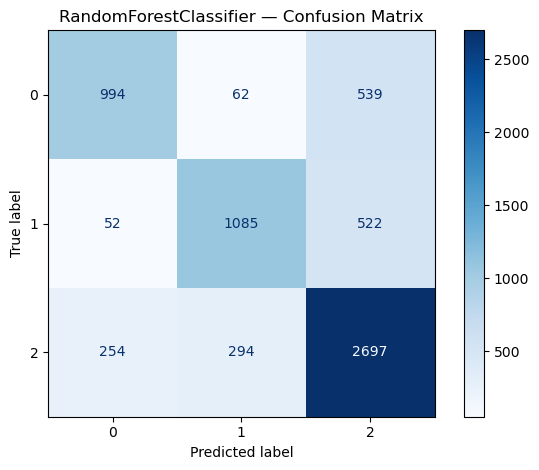

In [96]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=None,
    bootstrap=False,
    class_weight='balanced',
    random_state=42
)

santiago_base = run_model_pipeline(rf_model, chile_combined)

### Candidate models

Duplicates removed: 1 (21,662 → 21,661 rows)

Training set : 15,162 rows × 13 features
Test set     : 6,499 rows

MODEL: XGBClassifier
Train Accuracy : 0.9811
Test Accuracy  : 0.6941
Train F1       : 0.9809
Test F1        : 0.6661
F1 Gap         : 0.3148

Classification Report:
              precision    recall  f1-score   support

        High       0.73      0.53      0.61      1595
         Low       0.76      0.56      0.64      1659
      Medium       0.66      0.85      0.75      3245

    accuracy                           0.69      6499
   macro avg       0.72      0.64      0.67      6499
weighted avg       0.71      0.69      0.69      6499



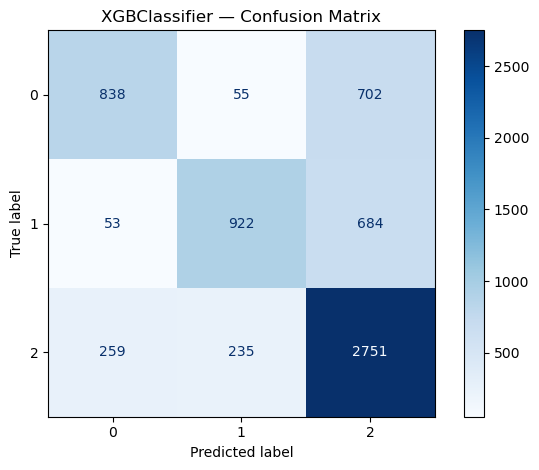

In [97]:
## XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=700,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.9,
    reg_alpha=0.05,
    reg_lambda=1.0,
    min_child_weight=1,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42
)
santiago_xgb = run_model_pipeline(xgb_model, chile_combined)

Duplicates removed: 1 (21,662 → 21,661 rows)

Training set : 15,162 rows × 13 features
Test set     : 6,499 rows

MODEL: KNeighborsClassifier
Train Accuracy : 1.0000
Test Accuracy  : 0.7366
Train F1       : 1.0000
Test F1        : 0.7249
F1 Gap         : 0.2751

Classification Report:
              precision    recall  f1-score   support

        High       0.71      0.66      0.69      1595
         Low       0.74      0.71      0.72      1659
      Medium       0.75      0.79      0.77      3245

    accuracy                           0.74      6499
   macro avg       0.73      0.72      0.72      6499
weighted avg       0.74      0.74      0.74      6499



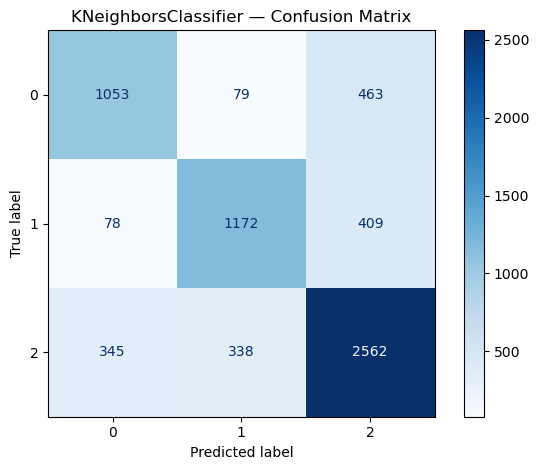

In [98]:
# KNN Model
knn_model = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    metric='manhattan'
)
santiago_knn = run_model_pipeline(knn_model, chile_combined)

Duplicates removed: 1 (21,662 → 21,661 rows)

Training set : 15,162 rows × 13 features
Test set     : 6,499 rows

MODEL: MLPClassifier
Train Accuracy : 0.6128
Test Accuracy  : 0.5866
Train F1       : 0.5485
Test F1        : 0.5161
F1 Gap         : 0.0324

Classification Report:
              precision    recall  f1-score   support

        High       0.59      0.26      0.36      1595
         Low       0.64      0.42      0.51      1659
      Medium       0.57      0.83      0.68      3245

    accuracy                           0.59      6499
   macro avg       0.60      0.50      0.52      6499
weighted avg       0.59      0.59      0.56      6499



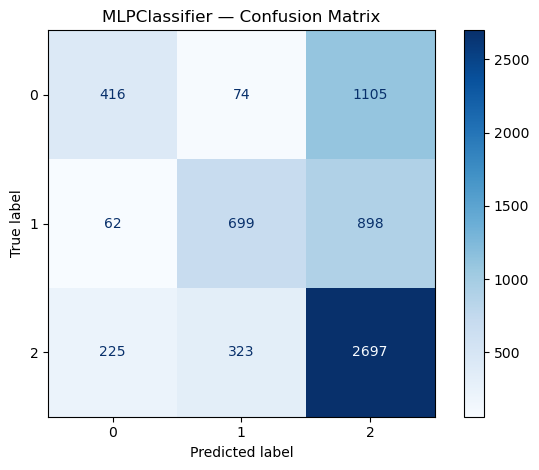

In [99]:
#MLP Model
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='tanh',
    alpha=0.0001,
    learning_rate_init=0.0005,
    batch_size=32,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
santiago_mlp = run_model_pipeline(mlp_model, chile_combined)

### ResidualMLP

In [100]:
# ════════════════════════════════════════════════════
#  Change these to match your file locations
# ════════════════════════════════════════════════════
CHILE_PATH   = 'chile_combined.csv'
BRAZIL_PATH  = 'brazil_combined.csv'
 
MODEL_FEATURES = [
    'median_NDVI', 'median_NDBI', 'median_NDWI',
    'NDVI_std',    'NDBI_std',    'NDWI_std',
    'NDMI',        'BSI',
    'building_density_100m', 'building_coverage',
    'avg_building_size',     'mean_building_height', 'weighted_height'
]
 
CLASS_MAP = {'High': 0, 'Low': 1, 'Medium': 2}
INV_MAP   = {0: 'High', 1: 'Low', 2: 'Medium'}
CLASSES   = ['High', 'Low', 'Medium']
 
# Train/test split ratio
TEST_SIZE    = 0.30
RANDOM_STATE = 42
 
# ── Neural network settings ───────────────────────────────────
# Architecture
NN_HIDDEN     = [256, 128, 64]
NN_BATCH_SIZE = 256
NN_EPOCHS     = 200          # was 150 — more room before early stop kicks in
 
# Regularisation  (key levers for overfitting)
NN_DROPOUT      = 0.40       # was 0.30 — more stochastic drop during training
NN_WEIGHT_DECAY = 5e-4       # was 1e-4 — stronger L2 on all weights
NN_GRAD_CLIP    = 1.0        # gradient norm clipping — stabilises noisy batches
NN_LABEL_SMOOTH = 0.05       # label smoothing — penalises overconfident outputs
 
# Optimiser / scheduler
NN_LR         = 0.001
NN_PATIENCE   = 30           # was 25 — give model a bit more time to recover
 
print('Configuration set')

Configuration set


In [101]:
chile = pd.read_csv(CHILE_PATH)
chile.columns = [c.strip() for c in chile.columns]
 
# Drop duplicates on features only
chile = chile.drop_duplicates(subset=MODEL_FEATURES).reset_index(drop=True)
 
# Encode labels
chile['label'] = chile['UHI_Class'].map(CLASS_MAP)
chile = chile.dropna(subset=['label'])
 
print(f'Santiago dataset: {len(chile):,} rows after deduplication')
print(f'\nClass distribution:')
for cls in CLASSES:
    n   = (chile['UHI_Class'] == cls).sum()
    pct = n / len(chile) * 100
    bar = '█' * int(pct / 2.5)
    print(f'  {cls:<8}: {n:>6,}  ({pct:.1f}%)  {bar}')
 
# Stratified split — keeps class ratios equal in train and test
X_raw = chile[MODEL_FEATURES].fillna(0).values
y     = chile['label'].astype(int).values
 
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)
 
print(f'\nSplit ({int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)}):')
print(f'  Training set: {len(y_train):,} rows')
print(f'  Test set:     {len(y_test):,} rows  ← held out, never touched during training')

Santiago dataset: 21,661 rows after deduplication

Class distribution:
  High    :  5,316  (24.5%)  █████████
  Low     :  5,529  (25.5%)  ██████████
  Medium  : 10,816  (49.9%)  ███████████████████

Split (70/30):
  Training set: 15,162 rows
  Test set:     6,499 rows  ← held out, never touched during training


In [102]:
# Fit ONLY on training data
scaler = StandardScaler()
scaler.fit(X_train_raw)
 
# Transform both sets using the same fitted scaler
X_train = scaler.transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)
 
print(f'Features scaled: {X_train.shape[1]} features')
print(f'Training mean (should be ~0): {X_train.mean():.4f}')
print(f'Training std  (should be ~1): {X_train.std():.4f}')
print(f'Test mean (close to 0):       {X_test.mean():.4f}')

Features scaled: 13 features
Training mean (should be ~0): -0.0000
Training std  (should be ~1): 1.0000
Test mean (close to 0):       -0.0049


In [103]:
if TORCH_OK:
    class ResidualBlock(nn.Module):
        """
        Two linear layers with a skip connection.
        The skip (shortcut) line passes the raw input directly to the output,
        so the network always has access to original feature values.
        """
        def __init__(self, in_dim, out_dim, dropout_rate=0.3):
            super().__init__()
            self.linear1 = nn.Linear(in_dim, out_dim)
            self.linear2 = nn.Linear(out_dim, out_dim)
            self.bn1     = nn.BatchNorm1d(out_dim)
            self.bn2     = nn.BatchNorm1d(out_dim)
            self.dropout = nn.Dropout(dropout_rate)
            self.relu    = nn.ReLU()
            self.skip    = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
 
        def forward(self, x):
            skip = self.skip(x)
            out  = self.relu(self.bn1(self.linear1(x)))
            out  = self.dropout(out)
            out  = self.bn2(self.linear2(out))
            return self.relu(out + skip)   # skip connection adds input back in
 
    class ResidualMLP(nn.Module):
        """Full Residual MLP: Input(13) → Block(256) → Block(128) → Block(64) → Output(3)"""
        def __init__(self, input_dim, hidden_dims, n_classes, dropout_rate=0.3):
            super().__init__()
            layers, in_d = [], input_dim
            for h in hidden_dims:
                layers.append(ResidualBlock(in_d, h, dropout_rate))
                in_d = h
            self.blocks  = nn.Sequential(*layers)
            self.dropout = nn.Dropout(dropout_rate)
            self.output  = nn.Linear(in_d, n_classes)
 
        def forward(self, x):
            return self.output(self.dropout(self.blocks(x)))
 
    print(f'ResidualMLP defined: {len(MODEL_FEATURES)} → {NN_HIDDEN} → 3')
else:
    print('PyTorch not available — ResidualMLP skipped')

ResidualMLP defined: 13 → [256, 128, 64] → 3


In [105]:
# Store results for comparison table at the end
results = {}
 
def evaluate(name, y_true, y_pred, y_pred_train=None, y_true_train=None):
    """
    Print classification report + confusion matrix.
    Also shows train F1 if provided, so you can spot overfitting.
    """
    test_f1  = f1_score(y_true, y_pred, average='macro')
    train_f1 = f1_score(y_true_train, y_pred_train, average='macro') if y_pred_train is not None else None
 
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    if train_f1 is not None:
        gap = train_f1 - test_f1
        flag = '  ← possible overfit' if gap > 0.10 else ''
        print(f'  Train F1 : {train_f1:.4f}')
        print(f'  Test  F1 : {test_f1:.4f}  (gap: {gap:+.4f}){flag}')
    else:
        print(f'  Test  F1 : {test_f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=CLASSES))
 
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
 
    results[name] = {'train_f1': train_f1, 'test_f1': test_f1}
    return test_f1
 
print('evaluate() defined')

evaluate() defined


Training Residual MLP for up to 200 epochs...
Device: cpu  |  Hidden: [256, 128, 64]  |  Dropout: 0.35  |  WD: 0.0003  |  LabelSmooth: 0.05  |  Mixup α: 0.2  |  SWA start: 60
──────────────────────────────────────────────────────────────────────
  Epoch  20/200  Train loss: 0.9686  Val F1: 0.5486  ← best  
  Epoch  40/200  Train loss: 0.9819  Val F1: 0.5608    
  Epoch  60/200  Train loss: 0.9181  Val F1: 0.5798    
  Epoch  80/200  Train loss: 0.8982  Val F1: 0.5970    [SWA]
  Epoch 100/200  Train loss: 0.8661  Val F1: 0.6053    [SWA]
  Epoch 120/200  Train loss: 0.8796  Val F1: 0.6075    [SWA]
  Epoch 140/200  Train loss: 0.8766  Val F1: 0.6131    [SWA]
  Epoch 160/200  Train loss: 0.8629  Val F1: 0.6113    [SWA]
  Epoch 180/200  Train loss: 0.8868  Val F1: 0.6174    [SWA]
  Epoch 200/200  Train loss: 0.8321  Val F1: 0.6181    [SWA]

Best base-model val F1: 0.6205


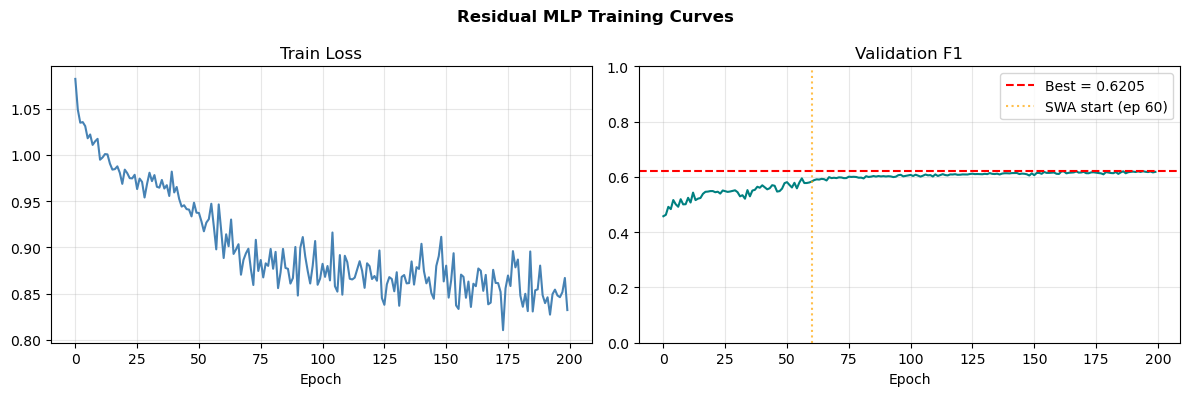


  Residual MLP
  Train F1 : 0.6632
  Test  F1 : 0.6060  (gap: +0.0572)

              precision    recall  f1-score   support

        High       0.52      0.69      0.59      1595
         Low       0.58      0.67      0.62      1659
      Medium       0.70      0.53      0.60      3245

    accuracy                           0.61      6499
   macro avg       0.60      0.63      0.61      6499
weighted avg       0.62      0.61      0.61      6499



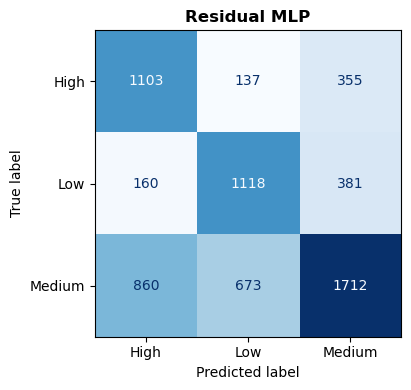

In [106]:
if TORCH_OK:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
 
 
    # ── Build tensors ─────────────────────────────────────────
    X_tr_t = torch.tensor(X_train, dtype=torch.float32)
    y_tr_t = torch.tensor(y_train, dtype=torch.long)
    X_te_t = torch.tensor(X_test,  dtype=torch.float32)
    y_te_t = torch.tensor(y_test,  dtype=torch.long)
 
    idx_tr, idx_va = train_test_split(
        np.arange(len(y_train)),
        test_size=0.30, stratify=y_train, random_state=RANDOM_STATE
    )
 
    tr_loader = DataLoader(
        TensorDataset(X_tr_t[idx_tr], y_tr_t[idx_tr]),
        batch_size=NN_BATCH_SIZE, shuffle=True
    )
    va_loader = DataLoader(
        TensorDataset(X_tr_t[idx_va], y_tr_t[idx_va]),
        batch_size=NN_BATCH_SIZE
    )
 
    # ── Model — capacity restored, regularisation dialled back ─
    # Gap was only 0.01 → the model was underfit, not overfit.
    # Increase hidden dims and ease off dropout / WD / label smoothing.
    NN_HIDDEN_TUNED = [256, 128, 64]   # restored from [128, 64, 32]
    DROPOUT_TUNED   = 0.35             # eased from 0.50
    WD_TUNED        = 3e-4             # eased from 1e-3
    LS_TUNED        = 0.05             # eased from 0.10
    MIXUP_ALPHA     = 0.2              # softer mix from 0.4 — less distortion
 
    res_mlp = ResidualMLP(
        input_dim=len(MODEL_FEATURES),
        hidden_dims=NN_HIDDEN_TUNED,
        n_classes=3,
        dropout_rate=DROPOUT_TUNED
    ).to(device)
 
    counts    = np.bincount(y_train)
    cw        = torch.tensor(1.0 / counts, dtype=torch.float32).to(device)
    cw        = cw / cw.sum() * 3
    criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=LS_TUNED)
 
    optimizer = optim.AdamW(res_mlp.parameters(), lr=NN_LR, weight_decay=WD_TUNED)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=30, T_mult=2, eta_min=1e-5
    )
 
    SWA_START = 60
    swa_model = AveragedModel(res_mlp)
    swa_sched = SWALR(optimizer, swa_lr=5e-5, anneal_epochs=10)
 
    # ── Training loop ─────────────────────────────────────────
    best_val_f1, best_weights, patience_counter = 0, None, 0
    train_losses, val_f1s = [], []
 
    print(f'Training Residual MLP for up to {NN_EPOCHS} epochs...')
    print(f'Device: {device}  |  Hidden: {NN_HIDDEN_TUNED}  |  '
          f'Dropout: {DROPOUT_TUNED}  |  WD: {WD_TUNED}  |  '
          f'LabelSmooth: {LS_TUNED}  |  Mixup α: {MIXUP_ALPHA}  |  '
          f'SWA start: {SWA_START}')
    print('─'*70)
 
    for epoch in range(NN_EPOCHS):
 
        # ── Train with Mixup ───────────────────────────────────
        res_mlp.train()
        epoch_loss = 0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(device), yb.to(device)
 
            lam     = np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA)
            idx_mix = torch.randperm(Xb.size(0), device=device)
            Xb_mix  = lam * Xb + (1 - lam) * Xb[idx_mix]
            yb_mix  = yb[idx_mix]
 
            optimizer.zero_grad()
            logits = res_mlp(Xb_mix)
            loss   = lam * criterion(logits, yb) + (1 - lam) * criterion(logits, yb_mix)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(res_mlp.parameters(), NN_GRAD_CLIP)
            optimizer.step()
            epoch_loss += loss.item()
 
        avg_loss = epoch_loss / len(tr_loader)
        train_losses.append(avg_loss)
 
        if epoch >= SWA_START:
            swa_model.update_parameters(res_mlp)
            swa_sched.step()
        else:
            scheduler.step(epoch + 1)
 
        # ── Validate ───────────────────────────────────────────
        res_mlp.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for Xb, yb in va_loader:
                logits = res_mlp(Xb.to(device))
                val_preds.extend(logits.argmax(dim=1).cpu().numpy())
                val_true.extend(yb.numpy())
 
        val_f1 = f1_score(val_true, val_preds, average='macro')
        val_f1s.append(val_f1)
 
        if val_f1 > best_val_f1:
            best_val_f1      = val_f1
            best_weights     = {k: v.clone() for k, v in res_mlp.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
 
        if (epoch + 1) % 20 == 0:
            print(f'  Epoch {epoch+1:3d}/{NN_EPOCHS}  '
                  f'Train loss: {avg_loss:.4f}  '
                  f'Val F1: {val_f1:.4f}  '
                  f'{"← best" if val_f1 == best_val_f1 else ""}  '
                  f'{"[SWA]" if epoch >= SWA_START else ""}')
 
        if patience_counter >= NN_PATIENCE:
            print(f'  Early stop at epoch {epoch+1}')
            break
 
    torch.optim.swa_utils.update_bn(tr_loader, swa_model, device=device)
    print(f'\nBest base-model val F1: {best_val_f1:.4f}')
 
    # ── Plot training curves ───────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Residual MLP Training Curves', fontweight='bold')
    axes[0].plot(train_losses, color='steelblue')
    axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True, alpha=0.3)
    axes[1].plot(val_f1s, color='teal')
    axes[1].axhline(best_val_f1, color='red', linestyle='--',
                    label=f'Best = {best_val_f1:.4f}')
    axes[1].axvline(SWA_START, color='orange', linestyle=':',
                    alpha=0.7, label=f'SWA start (ep {SWA_START})')
    axes[1].set_title('Validation F1'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
 
    # ── Evaluate SWA model on untouched test set ───────────────
    swa_model.eval()
    with torch.no_grad():
        nn_test_probs  = torch.softmax(swa_model(X_te_t.to(device)), dim=1).cpu().numpy()
        nn_train_probs = torch.softmax(swa_model(X_tr_t.to(device)), dim=1).cpu().numpy()
 
    nn_test_preds  = nn_test_probs.argmax(axis=1)
    nn_train_preds = nn_train_probs.argmax(axis=1)
 
    evaluate(
        'Residual MLP',
        y_test,  nn_test_preds,
        y_train, nn_train_preds
    )
else:
    print('Residual MLP skipped — PyTorch not available')
    nn_test_probs = None

---
## Model Building - Rio de Janeiro (Benchmark)


### Random Forest (base model)

Duplicates removed: 3,969 (28,488 → 24,519 rows)

Training set : 17,163 rows × 13 features
Test set     : 7,356 rows

MODEL: RandomForestClassifier
Train Accuracy : 0.9981
Test Accuracy  : 0.9159
Train F1       : 0.9975
Test F1        : 0.8931
F1 Gap         : 0.1044

Classification Report:
              precision    recall  f1-score   support

        High       0.92      0.95      0.93      3304
         Low       0.94      0.95      0.95      2727
      Medium       0.85      0.75      0.80      1325

    accuracy                           0.92      7356
   macro avg       0.90      0.89      0.89      7356
weighted avg       0.91      0.92      0.91      7356



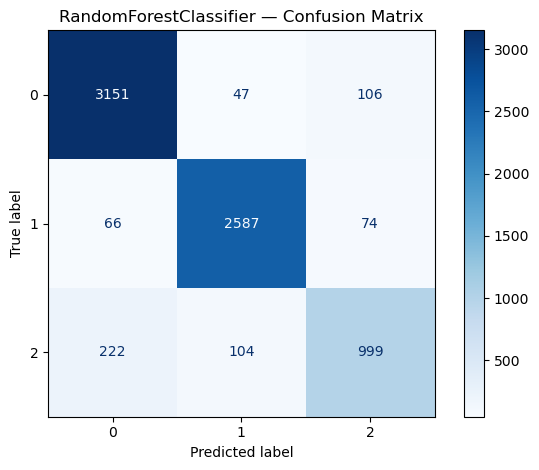

In [107]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='log2',
    max_depth=None,
    bootstrap=False,
    class_weight='balanced',
    random_state=42
)

rio_base = run_model_pipeline(rf_model, brazil_combined)

### Candidate models

Duplicates removed: 3,969 (28,488 → 24,519 rows)

Training set : 17,163 rows × 13 features
Test set     : 7,356 rows

MODEL: XGBClassifier
Train Accuracy : 0.9953
Test Accuracy  : 0.9093
Train F1       : 0.9940
Test F1        : 0.8805
F1 Gap         : 0.1135

Classification Report:
              precision    recall  f1-score   support

        High       0.90      0.96      0.93      3304
         Low       0.94      0.95      0.95      2727
      Medium       0.87      0.68      0.77      1325

    accuracy                           0.91      7356
   macro avg       0.90      0.87      0.88      7356
weighted avg       0.91      0.91      0.91      7356



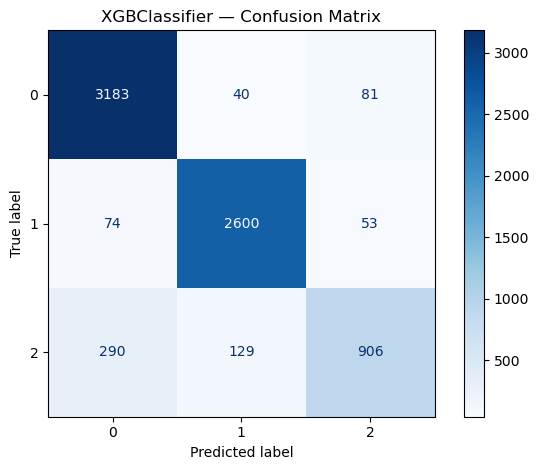

In [108]:
## XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=700,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.9,
    reg_alpha=0.05,
    reg_lambda=1.0,
    min_child_weight=1,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42
)
rio_xgb = run_model_pipeline(xgb_model, brazil_combined)

Duplicates removed: 3,969 (28,488 → 24,519 rows)

Training set : 17,163 rows × 13 features
Test set     : 7,356 rows

MODEL: KNeighborsClassifier
Train Accuracy : 1.0000
Test Accuracy  : 0.9202
Train F1       : 1.0000
Test F1        : 0.8994
F1 Gap         : 0.1006

Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.94      0.94      3304
         Low       0.95      0.95      0.95      2727
      Medium       0.82      0.79      0.81      1325

    accuracy                           0.92      7356
   macro avg       0.90      0.90      0.90      7356
weighted avg       0.92      0.92      0.92      7356



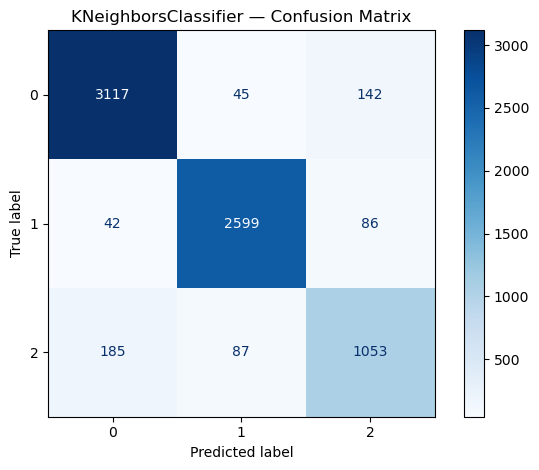

In [109]:
# KNN Model
knn_model = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    metric='manhattan'
)
rio_knn = run_model_pipeline(knn_model, brazil_combined)

Duplicates removed: 3,969 (28,488 → 24,519 rows)

Training set : 17,163 rows × 13 features
Test set     : 7,356 rows

MODEL: MLPClassifier
Train Accuracy : 0.8092
Test Accuracy  : 0.7974
Train F1       : 0.7261
Test F1        : 0.7113
F1 Gap         : 0.0148

Classification Report:
              precision    recall  f1-score   support

        High       0.78      0.92      0.84      3304
         Low       0.87      0.88      0.87      2727
      Medium       0.63      0.31      0.42      1325

    accuracy                           0.80      7356
   macro avg       0.76      0.71      0.71      7356
weighted avg       0.78      0.80      0.78      7356



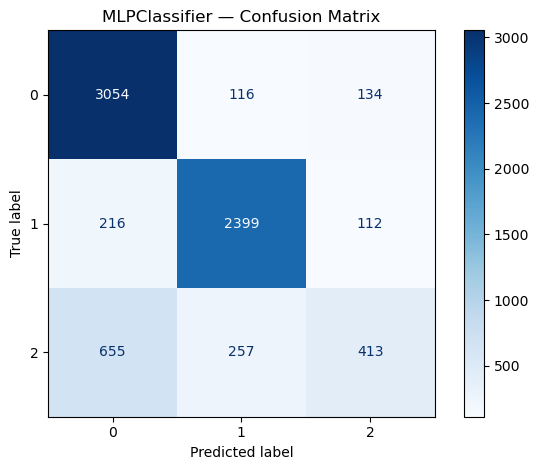

In [110]:
#MLP Model
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='tanh',
    alpha=0.0001,
    learning_rate_init=0.0005,
    batch_size=32,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
rio_mlp = run_model_pipeline(mlp_model, brazil_combined)

### ResidualMLP

In [111]:
# Drop duplicates on features only
brazil = brazil_combined.drop_duplicates(subset=MODEL_FEATURES).reset_index(drop=True)

# Encode labels
brazil['label'] = brazil['UHI_Class'].map(CLASS_MAP)
brazil = brazil.dropna(subset=['label'])

print(f'Santiago dataset: {len(brazil):,} rows after deduplication')
print(f'\nClass distribution:')
for cls in CLASSES:
    n   = (brazil['UHI_Class'] == cls).sum()
    pct = n / len(brazil) * 100
    bar = '█' * int(pct / 2.5)
    print(f'  {cls:<8}: {n:>6,}  ({pct:.1f}%)  {bar}')

# Stratified split — keeps class ratios equal in train and test
X_raw = brazil[MODEL_FEATURES].fillna(0).values
y     = brazil['label'].astype(int).values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'\nSplit ({int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)}):')
print(f'  Training set: {len(y_train):,} rows')
print(f'  Test set:     {len(y_test):,} rows  ← held out, never touched during training')

Santiago dataset: 24,519 rows after deduplication

Class distribution:
  High    : 11,014  (44.9%)  █████████████████
  Low     :  9,088  (37.1%)  ██████████████
  Medium  :  4,417  (18.0%)  ███████

Split (70/30):
  Training set: 17,163 rows
  Test set:     7,356 rows  ← held out, never touched during training


In [112]:
# Fit ONLY on training data
scaler = StandardScaler()
scaler.fit(X_train_raw)

# Transform both sets using the same fitted scaler
X_train = scaler.transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Features scaled: {X_train.shape[1]} features')
print(f'Training mean (should be ~0): {X_train.mean():.4f}')
print(f'Training std  (should be ~1): {X_train.std():.4f}')
print(f'Test mean (close to 0):       {X_test.mean():.4f}')

Features scaled: 13 features
Training mean (should be ~0): -0.0000
Training std  (should be ~1): 1.0000
Test mean (close to 0):       0.0054


In [113]:
if TORCH_OK:
    class ResidualBlock(nn.Module):
        """
        Two linear layers with a skip connection.
        The skip (shortcut) line passes the raw input directly to the output,
        so the network always has access to original feature values.
        """
        def __init__(self, in_dim, out_dim, dropout_rate=0.3):
            super().__init__()
            self.linear1 = nn.Linear(in_dim, out_dim)
            self.linear2 = nn.Linear(out_dim, out_dim)
            self.bn1     = nn.BatchNorm1d(out_dim)
            self.bn2     = nn.BatchNorm1d(out_dim)
            self.dropout = nn.Dropout(dropout_rate)
            self.relu    = nn.ReLU()
            self.skip    = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

        def forward(self, x):
            skip = self.skip(x)
            out  = self.relu(self.bn1(self.linear1(x)))
            out  = self.dropout(out)
            out  = self.bn2(self.linear2(out))
            return self.relu(out + skip)   # skip connection adds input back in

    class ResidualMLP(nn.Module):
        """Full Residual MLP: Input(13) → Block(256) → Block(128) → Block(64) → Output(3)"""
        def __init__(self, input_dim, hidden_dims, n_classes, dropout_rate=0.3):
            super().__init__()
            layers, in_d = [], input_dim
            for h in hidden_dims:
                layers.append(ResidualBlock(in_d, h, dropout_rate))
                in_d = h
            self.blocks  = nn.Sequential(*layers)
            self.dropout = nn.Dropout(dropout_rate)
            self.output  = nn.Linear(in_d, n_classes)

        def forward(self, x):
            return self.output(self.dropout(self.blocks(x)))

    print(f'ResidualMLP defined: {len(MODEL_FEATURES)} → {NN_HIDDEN} → 3')
else:
    print('PyTorch not available — ResidualMLP skipped')

ResidualMLP defined: 13 → [256, 128, 64] → 3


In [114]:
# Store results for comparison table at the end
results = {}

def evaluate(name, y_true, y_pred, y_pred_train=None, y_true_train=None):
    """
    Print classification report + confusion matrix.
    Also shows train F1 if provided, so you can spot overfitting.
    """
    test_f1  = f1_score(y_true, y_pred, average='macro')
    train_f1 = f1_score(y_true_train, y_pred_train, average='macro') if y_pred_train is not None else None

    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    if train_f1 is not None:
        gap = train_f1 - test_f1
        flag = '  ← possible overfit' if gap > 0.10 else ''
        print(f'  Train F1 : {train_f1:.4f}')
        print(f'  Test  F1 : {test_f1:.4f}  (gap: {gap:+.4f}){flag}')
    else:
        print(f'  Test  F1 : {test_f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

    results[name] = {'train_f1': train_f1, 'test_f1': test_f1}
    return test_f1

print('evaluate() defined')

evaluate() defined


Training Residual MLP for up to 200 epochs...
Device: cpu  |  Early stop patience: 25 epochs
───────────────────────────────────────────────────────
  Epoch  20/200  Train loss: 0.5929  Val F1: 0.7245  ← best
  Epoch  40/200  Train loss: 0.4486  Val F1: 0.7766  
  Epoch  60/200  Train loss: 0.3560  Val F1: 0.8239  
  Epoch  80/200  Train loss: 0.2792  Val F1: 0.8495  
  Epoch 100/200  Train loss: 0.2314  Val F1: 0.8729  ← best
  Epoch 120/200  Train loss: 0.1805  Val F1: 0.8788  
  Epoch 140/200  Train loss: 0.1344  Val F1: 0.8889  
  Epoch 160/200  Train loss: 0.1176  Val F1: 0.8955  
  Early stop at epoch 177

Best validation F1: 0.8971


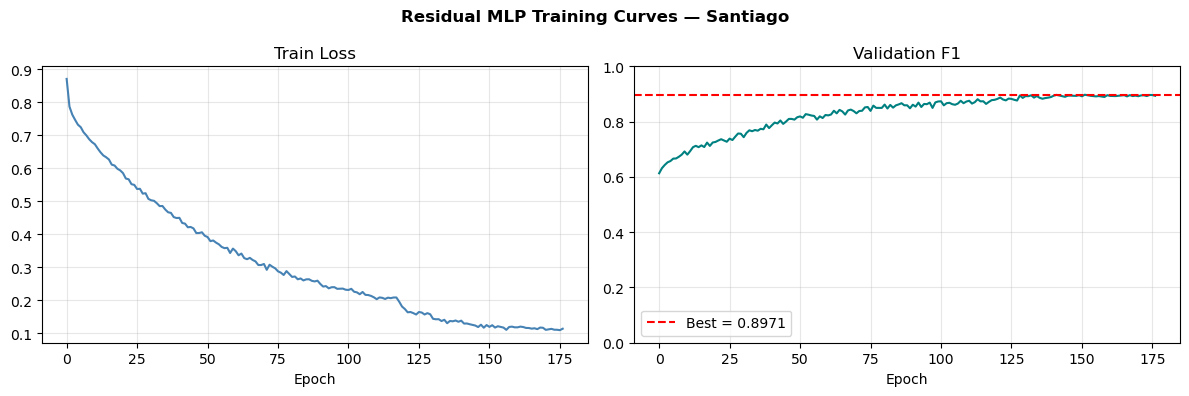


  Residual MLP
  Train F1 : 0.9548
  Test  F1 : 0.9038  (gap: +0.0511)

              precision    recall  f1-score   support

        High       0.96      0.92      0.94      3304
         Low       0.96      0.96      0.96      2727
      Medium       0.77      0.86      0.82      1325

    accuracy                           0.92      7356
   macro avg       0.90      0.91      0.90      7356
weighted avg       0.93      0.92      0.92      7356



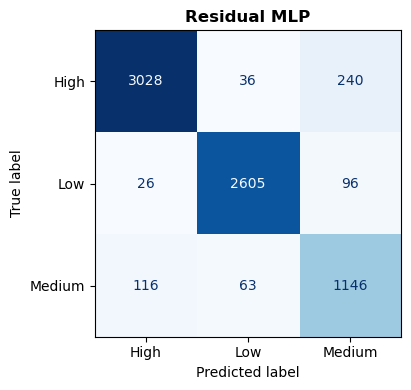

In [115]:
if TORCH_OK:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # ── Build tensors ─────────────────────────────────────────
    # Use the already-scaled X_train / X_test
    X_tr_t = torch.tensor(X_train, dtype=torch.float32)
    y_tr_t = torch.tensor(y_train, dtype=torch.long)
    X_te_t = torch.tensor(X_test,  dtype=torch.float32)
    y_te_t = torch.tensor(y_test,  dtype=torch.long)

    # Internal train/val split for early stopping (15% of training data)
    idx_tr, idx_va = train_test_split(
        np.arange(len(y_train)),
        test_size=0.15, stratify=y_train, random_state=RANDOM_STATE
    )

    tr_loader = DataLoader(
        TensorDataset(X_tr_t[idx_tr], y_tr_t[idx_tr]),
        batch_size=NN_BATCH_SIZE, shuffle=True
    )
    va_loader = DataLoader(
        TensorDataset(X_tr_t[idx_va], y_tr_t[idx_va]),
        batch_size=NN_BATCH_SIZE
    )

    # ── Model, loss, optimiser ────────────────────────────────
    res_mlp = ResidualMLP(
        input_dim=len(MODEL_FEATURES),
        hidden_dims=NN_HIDDEN,
        n_classes=3,
        dropout_rate=NN_DROPOUT
    ).to(device)

    # Class-weighted loss to handle imbalance
    counts    = np.bincount(y_train)
    cw        = torch.tensor(1.0 / counts, dtype=torch.float32).to(device)
    cw        = cw / cw.sum() * 3
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = optim.AdamW(res_mlp.parameters(), lr=NN_LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )

    # ── Training loop ─────────────────────────────────────────
    best_val_f1, best_weights, patience_counter = 0, None, 0
    train_losses, val_f1s = [], []

    print(f'Training Residual MLP for up to {NN_EPOCHS} epochs...')
    print(f'Device: {device}  |  Early stop patience: 25 epochs')
    print('─'*55)

    for epoch in range(NN_EPOCHS):

        # Train
        res_mlp.train()
        epoch_loss = 0
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(res_mlp(Xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(tr_loader)
        train_losses.append(avg_loss)

        # Validate
        res_mlp.eval()
        val_preds, val_true, val_loss = [], [], 0
        with torch.no_grad():
            for Xb, yb in va_loader:
                Xb = Xb.to(device)
                logits = res_mlp(Xb)
                val_loss += criterion(logits, yb.to(device)).item()
                val_preds.extend(logits.argmax(dim=1).cpu().numpy())
                val_true.extend(yb.numpy())

        val_f1 = f1_score(val_true, val_preds, average='macro')
        val_f1s.append(val_f1)
        scheduler.step(val_loss / len(va_loader))

        # Save best
        if val_f1 > best_val_f1:
            best_val_f1      = val_f1
            best_weights     = {k: v.clone() for k, v in res_mlp.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 20 == 0:
            print(f'  Epoch {epoch+1:3d}/{NN_EPOCHS}  '
                  f'Train loss: {avg_loss:.4f}  '
                  f'Val F1: {val_f1:.4f}  '
                  f'{"← best" if val_f1 == best_val_f1 else ""}')

        if patience_counter >= 25:
            print(f'  Early stop at epoch {epoch+1}')
            break

    # Restore best weights
    res_mlp.load_state_dict(best_weights)
    print(f'\nBest validation F1: {best_val_f1:.4f}')

    # ── Plot training curves ───────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Residual MLP Training Curves — Santiago', fontweight='bold')
    axes[0].plot(train_losses, color='steelblue')
    axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch'); axes[0].grid(True, alpha=0.3)
    axes[1].plot(val_f1s, color='teal')
    axes[1].axhline(best_val_f1, color='red', linestyle='--',
                    label=f'Best = {best_val_f1:.4f}')
    axes[1].set_title('Validation F1'); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # ── Evaluate on test set ───────────────────────────────────
    res_mlp.eval()
    with torch.no_grad():
        nn_test_probs  = torch.softmax(res_mlp(X_te_t.to(device)), dim=1).cpu().numpy()
        nn_train_probs = torch.softmax(res_mlp(X_tr_t.to(device)), dim=1).cpu().numpy()

    nn_test_preds  = nn_test_probs.argmax(axis=1)
    nn_train_preds = nn_train_probs.argmax(axis=1)

    evaluate(
        'Residual MLP',
        y_test,  nn_test_preds,
        y_train, nn_train_preds
    )
else:
    print('Residual MLP skipped — PyTorch not available')
    nn_test_probs = None

---
##  Model Building - Freetown (Main Target)

Freetown has no ground-truth labels. We use:
- Chile + Brazil as training data
- `freetown_labeled_enhanced.csv` — confirmed + recovered Freetown labels
- Pseudo-labeling to adapt the model to Freetown's geography

### Data preparation

Combining South America training data with confirmed Freetown labels.  
Scale features using a shared StandardScaler fitted on ALL regions combined  
- this is the key step that stops Freetown features from looking like outliers.

In [ ]:
# Setting up ranked and labeled versions of each dataset
chile_r   = chile_combined.copy()
brazil_r  = brazil_combined.copy()
sierra_r  = sierra_combined.copy()
freetown_r = freetown_labeled.copy() if 'freetown_labeled' in dir() else None

# Combining Chile + Brazil as South America training set
combined_train = pd.concat([chile_r, brazil_r], ignore_index=True)

print(f'South America training set: {len(combined_train):,} rows')
if freetown_r is not None:
    print(f'Labeled Freetown data:      {len(freetown_r):,} rows')
print(f'Freetown test set:          {len(sierra_r):,} rows')

South America training set: 50,150 rows
Labeled Freetown data:      11,179 rows
Freetown test set:          14,105 rows


In [ ]:
def within_region_rank(df, features, n_quantiles=500):
    """
    Normalise each region by its own distribution.
    Each value → percentile rank [0,1] within its own city.
    Prevents absolute pixel value differences between cities from confusing the model.
    """
    df_out = df.copy()
    valid  = [f for f in features if f in df.columns]
    qt = QuantileTransformer(
        n_quantiles=min(n_quantiles, len(df)),
        output_distribution='uniform',
        random_state=42
    )
    df_out[valid] = qt.fit_transform(df[valid].fillna(df[valid].median()))
    return df_out, qt

chile_r,  _ = within_region_rank(chile_r,  MODEL_FEATURES)
brazil_r, _ = within_region_rank(brazil_r, MODEL_FEATURES)
sierra_r, _ = within_region_rank(sierra_r, MODEL_FEATURES)

if freetown_labeled is not None:
    freetown_r, _ = within_region_rank(freetown_labeled, MODEL_FEATURES)
else:
    freetown_r = None

print(' Within-region rank normalisation complete')

 Within-region rank normalisation complete


In [ ]:
# ── South America training set ────────────────────────────────
chile_r['label']  = chile_r['UHI_Class'].map(CLASS_MAP)
brazil_r['label'] = brazil_r['UHI_Class'].map(CLASS_MAP)

train_sa = pd.concat([chile_r, brazil_r], ignore_index=True)
train_sa['sample_weight'] = 1.0  # standard weight for South America

# ── Freetown labeled data ─────────────────────────────────────
if freetown_r is not None:
    # Use label_confidence as sample weight
    # → confirmed real labels (conf=1.0) count fully
    # → recovered labels (conf~0.6-0.8) count proportionally
    freetown_r['sample_weight'] = freetown_r['label_confidence'].clip(0.5, 1.0)
    train_all = pd.concat([train_sa, freetown_r], ignore_index=True)
else:
    train_all = train_sa

train_all = train_all.dropna(subset=['label'])

X_all = train_all[MODEL_FEATURES].fillna(0).values
y_all = train_all['label'].astype(int).values
W_all = train_all['sample_weight'].fillna(1.0).values  # sample weights

# Freetown test set (all 14,105 points, no labels)
X_ft = sierra_r[MODEL_FEATURES].fillna(0).values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Training set composition:')
if freetown_r is not None:
    print(f'  South America:          {len(train_sa):,}')
    print(f'  Freetown (enhanced):    {len(freetown_r):,}')
print(f'  Total:                  {len(X_all):,}')
print(f'\nFreetown test set:        {len(X_ft):,}')

Training set composition:
  South America:          50,150
  Freetown (enhanced):    11,179
  Total:                  61,329

Freetown test set:        14,105


### Tree ensemble (LightGBM · XGBoost · ExtraTrees · Random Forest)

Each model trains on the full combined dataset (SA + Freetown labels).  
We evaluate with 5-fold cross-validation before moving to pseudo-labeling.

In [ ]:
print('Training tree ensemble models...')
print('─'*50)

# LightGBM — fastest, handles imbalance well with class_weight
lgbm = LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    num_leaves=60,     class_weight='balanced',
    subsample=0.9,     colsample_bytree=0.85,
    reg_alpha=0.1,     reg_lambda=0.1,
    min_child_samples=10, random_state=42, verbose=-1
)
lgbm.fit(X_all, y_all, sample_weight=W_all)
lgbm_cv = cross_val_score(lgbm, X_all, y_all, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'LightGBM  CV F1: {lgbm_cv.mean():.4f} ± {lgbm_cv.std():.4f}')

# XGBoost — strong regularisation, handles feature interactions
xgb = XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=5,
    subsample=0.85, colsample_bytree=0.85,
    reg_alpha=0.1,  reg_lambda=1.0,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, verbosity=0
)
xgb.fit(X_all, y_all, sample_weight=W_all)
xgb_cv = cross_val_score(xgb, X_all, y_all, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'XGBoost   CV F1: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')

# ExtraTrees — maximally random trees, strong generalisation
et = ExtraTreesClassifier(
    n_estimators=700, max_depth=20, min_samples_split=2,
    min_samples_leaf=1, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1
)
et.fit(X_all, y_all, sample_weight=W_all)
et_cv = cross_val_score(et, X_all, y_all, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'ExtraTrees CV F1: {et_cv.mean():.4f} ± {et_cv.std():.4f}')

# RandomForest — your team's baseline, now with all 13 features
rf = RandomForestClassifier(
    n_estimators=700, max_depth=20, min_samples_split=2,
    min_samples_leaf=1, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_all, y_all, sample_weight=W_all)
rf_cv = cross_val_score(rf, X_all, y_all, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'RandomForest CV F1: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')

Training tree ensemble models...
──────────────────────────────────────────────────
LightGBM  CV F1: 0.8072 ± 0.0023
XGBoost   CV F1: 0.7715 ± 0.0024
ExtraTrees CV F1: 0.8323 ± 0.0026
RandomForest CV F1: 0.8280 ± 0.0029


### Residual MLP neural network


In [ ]:
if TORCH_OK:
    # ── Network definition ────────────────────────────────────
    class ResidualBlock(nn.Module):
        """One residual block: two linear layers with a skip connection."""
        def __init__(self, in_dim, out_dim, dropout_rate=0.3):
            super().__init__()
            self.linear1  = nn.Linear(in_dim, out_dim)
            self.linear2  = nn.Linear(out_dim, out_dim)
            self.bn1      = nn.BatchNorm1d(out_dim)
            self.bn2      = nn.BatchNorm1d(out_dim)
            self.dropout  = nn.Dropout(dropout_rate)
            self.relu     = nn.ReLU()
            # Project input dimension if different from output
            self.skip     = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        
        def forward(self, x):
            skip = self.skip(x)
            out  = self.relu(self.bn1(self.linear1(x)))
            out  = self.dropout(out)
            out  = self.bn2(self.linear2(out))
            # Add input (skip) to output — this is the residual connection
            # It prevents gradient vanishing and preserves raw feature info
            return self.relu(out + skip)
    
    class ResidualMLP(nn.Module):
        """
        Residual MLP for tabular UHI classification.
        
        Architecture:
          Input → Block(13→256) → Block(256→128) → Block(128→64) → Output(64→3)
          Each block has a skip connection preserving input features.
        """
        def __init__(self, input_dim, hidden_dims, n_classes, dropout_rate=0.3):
            super().__init__()
            
            layers = []
            in_dim = input_dim
            for hidden_dim in hidden_dims:
                layers.append(ResidualBlock(in_dim, hidden_dim, dropout_rate))
                in_dim = hidden_dim
            
            self.blocks    = nn.Sequential(*layers)
            self.output    = nn.Linear(in_dim, n_classes)
            self.dropout   = nn.Dropout(dropout_rate)
        
        def forward(self, x):
            x = self.blocks(x)
            x = self.dropout(x)
            return self.output(x)  # raw logits — CrossEntropyLoss expects this
    
    print(' ResidualMLP architecture defined')
    print(f'   Input: {len(MODEL_FEATURES)} features')
    print(f'   Layers: {len(MODEL_FEATURES)} → {" → ".join(str(h) for h in NN_HIDDEN)} → 3 classes')
else:
    print('  Skipping neural network (PyTorch not available)')

    

 ResidualMLP architecture defined
   Input: 13 features
   Layers: 13 → 256 → 128 → 64 → 3 classes


In [ ]:
if TORCH_OK:
    # ── Prepare tensors ───────────────────────────────────────
    X_t = torch.tensor(X_all, dtype=torch.float32)
    y_t = torch.tensor(y_all, dtype=torch.long)
    W_t = torch.tensor(W_all, dtype=torch.float32)
    
    # Train / validation split (stratified)
    from sklearn.model_selection import train_test_split
    idx_train, idx_val = train_test_split(
        np.arange(len(X_all)), test_size=0.15,
        stratify=y_all, random_state=42
    )
    
    train_ds = TensorDataset(X_t[idx_train], y_t[idx_train], W_t[idx_train])
    val_ds   = TensorDataset(X_t[idx_val],   y_t[idx_val],   W_t[idx_val])
    
    train_loader = DataLoader(train_ds, batch_size=NN_BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=NN_BATCH_SIZE, shuffle=False)
    
    #  Initialise model 
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')
    
    nn_model = ResidualMLP(
        input_dim   = len(MODEL_FEATURES),
        hidden_dims = NN_HIDDEN,
        n_classes   = 3,
        dropout_rate = NN_DROPOUT
    ).to(device)
    
    # Class-weighted loss to handle imbalance (same as class_weight='balanced' in sklearn)
    class_counts = np.bincount(y_all)
    class_weights = torch.tensor(
        1.0 / class_counts, dtype=torch.float32
    ).to(device)
    class_weights = class_weights / class_weights.sum() * 3  # normalise
    
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(nn_model.parameters(), lr=NN_LR, weight_decay=1e-4)
    
    # Learning rate scheduler — reduce LR when validation loss plateaus
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )
    
    #  Training loop 
    train_losses, val_losses, val_f1s = [], [], []
    best_val_f1  = 0
    best_weights = None
    patience_counter = 0
    EARLY_STOP_PATIENCE = 25
    
    print(f'\nTraining ResidualMLP for {NN_EPOCHS} epochs...')
    print('─'*55)
    
    for epoch in range(NN_EPOCHS):
        #  Train 
        nn_model.train()
        epoch_loss = 0
        for X_batch, y_batch, w_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            logits = nn_model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_train_loss = epoch_loss / len(train_loader)
        
        # ── Validate ─────────────────────────────────────────
        nn_model.eval()
        val_preds, val_true = [], []
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch, _ in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                logits  = nn_model(X_batch)
                val_loss += criterion(logits, y_batch).item()
                preds = logits.argmax(dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_true.extend(y_batch.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        epoch_f1     = f1_score(val_true, val_preds, average='macro')
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_f1s.append(epoch_f1)
        
        scheduler.step(avg_val_loss)
        
        # Save best model
        if epoch_f1 > best_val_f1:
            best_val_f1  = epoch_f1
            best_weights = {k: v.clone() for k, v in nn_model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 20 == 0:
            print(f'  Epoch {epoch+1:3d}/{NN_EPOCHS} | '
                  f'Train loss: {avg_train_loss:.4f} | '
                  f'Val loss: {avg_val_loss:.4f} | '
                  f'Val F1: {epoch_f1:.4f}  '
                  f'{"← best" if epoch_f1 == best_val_f1 else ""}')
        
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'\n  Early stopping at epoch {epoch+1} (no improvement for {EARLY_STOP_PATIENCE} epochs)')
            break
    
    # Restore best weights
    nn_model.load_state_dict(best_weights)
    print(f'\nBest validation F1: {best_val_f1:.4f}')
    print(' Neural network training complete')
else:
    print('  Skipping neural network training')

    

Using device: cpu

Training ResidualMLP for 150 epochs...
───────────────────────────────────────────────────────
  Epoch  20/150 | Train loss: 0.5687 | Val loss: 0.5233 | Val F1: 0.7763  ← best
  Epoch  40/150 | Train loss: 0.4455 | Val loss: 0.4379 | Val F1: 0.8184  
  Epoch  60/150 | Train loss: 0.3808 | Val loss: 0.3942 | Val F1: 0.8405  ← best
  Epoch  80/150 | Train loss: 0.3380 | Val loss: 0.3763 | Val F1: 0.8548  ← best
  Epoch 100/150 | Train loss: 0.3055 | Val loss: 0.3628 | Val F1: 0.8588  
  Epoch 120/150 | Train loss: 0.2789 | Val loss: 0.3552 | Val F1: 0.8652  
  Epoch 140/150 | Train loss: 0.2387 | Val loss: 0.3483 | Val F1: 0.8754  ← best

Best validation F1: 0.8793
 Neural network training complete


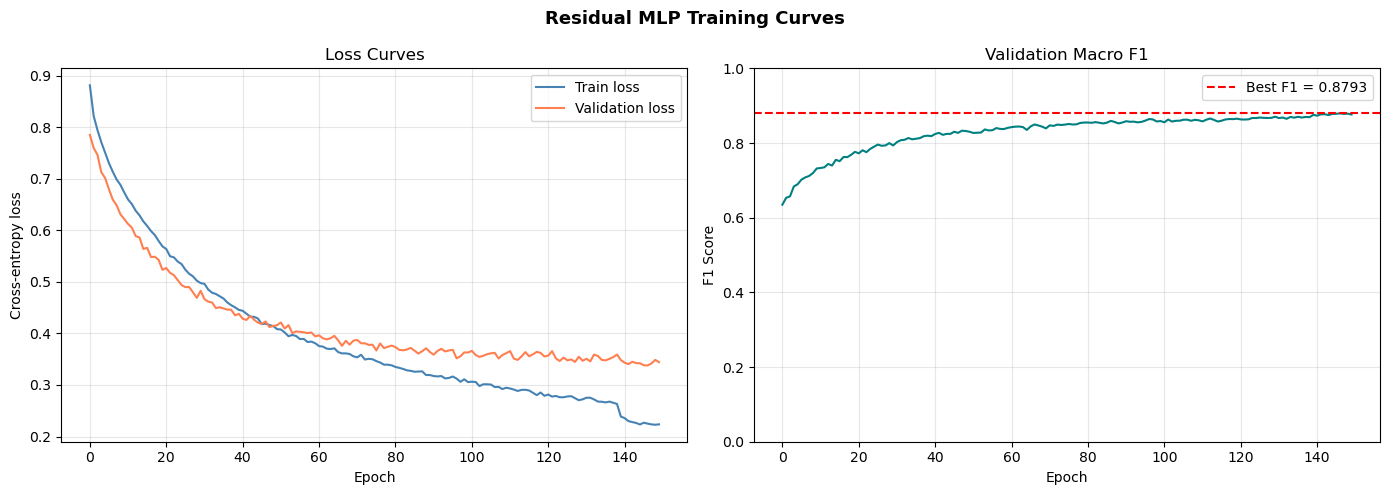

 Saved: nn_training_curves.png


In [ ]:
if TORCH_OK:
    #  Training curve visualisation 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Residual MLP Training Curves', fontsize=13, fontweight='bold')
    
    ax = axes[0]
    ax.plot(train_losses, label='Train loss',      color='steelblue', linewidth=1.5)
    ax.plot(val_losses,   label='Validation loss', color='coral',     linewidth=1.5)
    ax.set_title('Loss Curves')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy loss')
    ax.legend(); ax.grid(True, alpha=0.3)
    
    ax = axes[1]
    ax.plot(val_f1s, color='teal', linewidth=1.5)
    ax.axhline(best_val_f1, color='red', linestyle='--',
               label=f'Best F1 = {best_val_f1:.4f}')
    ax.set_title('Validation Macro F1')
    ax.set_xlabel('Epoch'); ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('nn_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Saved: nn_training_curves.png')

    

In [ ]:
def get_nn_proba(model, X, device, batch_size=512):
    """Get class probabilities from PyTorch neural net."""
    model.eval()
    X_t    = torch.tensor(X, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_t), batch_size=batch_size, shuffle=False)
    probs  = []
    with torch.no_grad():
        for (X_batch,) in loader:
            logits = model(X_batch.to(device))
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(probs)

#  Get probabilities from all models on Freetown 
print('Generating Freetown predictions from all models...')

probs_lgbm = lgbm.predict_proba(X_ft)
probs_xgb  = xgb.predict_proba(X_ft)
probs_et   = et.predict_proba(X_ft)
probs_rf   = rf.predict_proba(X_ft)

if TORCH_OK:
    probs_nn = get_nn_proba(nn_model, X_ft, device)
    # Weighted average: tree models get weight 1.0, neural net 0.8
    # (adjust this ratio based on individual CV scores)
    tree_weight = 1.0
    nn_weight   = 0.8
    probs_ensemble = (
        probs_lgbm * tree_weight +
        probs_xgb  * tree_weight +
        probs_et   * tree_weight +
        probs_rf   * tree_weight +
        probs_nn   * nn_weight
    ) / (4 * tree_weight + nn_weight)
    print('  Ensemble = LGBM + XGB + ET + RF + Neural Net (weighted avg)')
else:
    probs_ensemble = (probs_lgbm + probs_xgb + probs_et + probs_rf) / 4
    print('  Ensemble = LGBM + XGB + ET + RF (neural net unavailable)')

ft_preds_raw = probs_ensemble.argmax(axis=1)
ft_conf_raw  = probs_ensemble.max(axis=1)

sierra_r['pred_raw']   = [INV_MAP[p] for p in ft_preds_raw]
sierra_r['confidence'] = ft_conf_raw

print('\nFreetown raw prediction distribution:')
for cls in CLASSES:
    n   = (sierra_r['pred_raw'] == cls).sum()
    pct = n / len(sierra_r) * 100
    print(f'  {cls:<8}: {n:>5,}  ({pct:.1f}%)')

Generating Freetown predictions from all models...
  Ensemble = LGBM + XGB + ET + RF + Neural Net (weighted avg)

Freetown raw prediction distribution:
  High    : 5,474  (38.8%)
  Low     : 3,305  (23.4%)
  Medium  : 5,326  (37.8%)


### Pseudo-labeling (tree ensemble)

Iteratively adds high-confidence Freetown predictions back into the tree model training set.  
Each round the models see more Freetown data and predictions improve.

In [ ]:
# Re-run pseudo-labeling with the full ensemble
X_aug = X_all.copy()
y_aug = y_all.copy()

print(f'Pseudo-labeling: {PSEUDO_ROUNDS} rounds, threshold={PSEUDO_THRESHOLD}')
print('─'*50)

for round_num in range(1, PSEUDO_ROUNDS + 1):
    # Train on current augmented set
    aug_lgbm = LGBMClassifier(
        n_estimators=700, learning_rate=0.05, max_depth=6,
        num_leaves=60, class_weight='balanced',
        random_state=42, verbose=-1
    )
    aug_lgbm.fit(X_aug, y_aug)
    
    probs_round = aug_lgbm.predict_proba(X_ft)
    preds_round = aug_lgbm.predict(X_ft)
    conf_round  = probs_round.max(axis=1)
    
    # Add high-confidence predictions to training
    mask = conf_round >= PSEUDO_THRESHOLD
    n_add = mask.sum()
    
    X_aug = np.vstack([X_aug, X_ft[mask]])
    y_aug = np.concatenate([y_aug, preds_round[mask]])
    
    cv_aug = cross_val_score(
        aug_lgbm, X_aug, y_aug,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='f1_macro', n_jobs=-1
    )
    print(f'  Round {round_num}: +{n_add:,} points | CV F1 = {cv_aug.mean():.4f}')

# Final fit on all augmented data
for m in [lgbm, xgb, et, rf]:
    m.fit(X_aug, y_aug)

print('\n Pseudo-labeling complete')

Pseudo-labeling: 3 rounds, threshold=0.7
──────────────────────────────────────────────────
  Round 1: +9,765 points | CV F1 = 0.8144
  Round 2: +11,070 points | CV F1 = 0.8384
  Round 3: +11,764 points | CV F1 = 0.8556

 Pseudo-labeling complete


In [ ]:
def spatial_smooth(df, pred_col, conf_col, k=7, conf_threshold=0.65):
    """
    Replace low-confidence predictions with the majority vote from
    K nearest geographic neighbours (haversine distance).
    Only modifies predictions below the confidence threshold.
    """
    coords_rad = np.radians(df[['Latitude', 'Longitude']].values)
    tree       = BallTree(coords_rad, metric='haversine')
    preds      = df[pred_col].copy().values
    low_conf   = df[conf_col].values < conf_threshold
    _, indices = tree.query(coords_rad, k=k + 1)
    n_changed  = 0
    for i in np.where(low_conf)[0]:
        neighbours = preds[indices[i][1:]]  # exclude self
        vote = Counter(neighbours).most_common(1)[0][0]
        if vote != preds[i]:
            preds[i] = vote
            n_changed += 1
    print(f'  Eligible for smoothing: {low_conf.sum():,}')
    print(f'  Changed: {n_changed:,} ({n_changed/len(df)*100:.1f}% of all points)')
    return preds

# Final ensemble predictions after pseudo-labeling
print('Generating final ensemble predictions...')
final_probs_lgbm = lgbm.predict_proba(X_ft)
final_probs_xgb  = xgb.predict_proba(X_ft)
final_probs_et   = et.predict_proba(X_ft)
final_probs_rf   = rf.predict_proba(X_ft)

if TORCH_OK:
    final_probs_nn = get_nn_proba(nn_model, X_ft, device)
    final_probs = (
        final_probs_lgbm + final_probs_xgb + final_probs_et +
        final_probs_rf   + final_probs_nn * 0.8
    ) / 4.8
else:
    final_probs = (final_probs_lgbm + final_probs_xgb + final_probs_et + final_probs_rf) / 4

final_preds_raw = final_probs.argmax(axis=1)
final_conf_raw  = final_probs.max(axis=1)

sierra_r['pred_raw']   = [INV_MAP[p] for p in final_preds_raw]
sierra_r['confidence'] = final_conf_raw

print('Applying spatial smoothing...')
sierra_r['pred_smooth'] = spatial_smooth(
    sierra_r, 'pred_raw', 'confidence',
    k=SMOOTH_K, conf_threshold=SMOOTH_THRESHOLD
)

print('\nFinal distribution:')
print(f'  {"Class":<10} {"Raw":>8} {"Smoothed":>10}')
for cls in CLASSES:
    n_r = (sierra_r['pred_raw']    == cls).sum()
    n_s = (sierra_r['pred_smooth'] == cls).sum()
    print(f'  {cls:<10} {n_r:>8,} {n_s:>10,}')

Generating final ensemble predictions...
Applying spatial smoothing...
  Eligible for smoothing: 1,476
  Changed: 339 (2.4% of all points)

Final distribution:
  Class           Raw   Smoothed
  High          5,421      5,387
  Low           3,310      3,312
  Medium        5,374      5,406


### Final visualisation and submission

Combining all model probabilities into a soft-vote ensemble.  
Applying spatial smoothing to fix any Low↔High jumps.

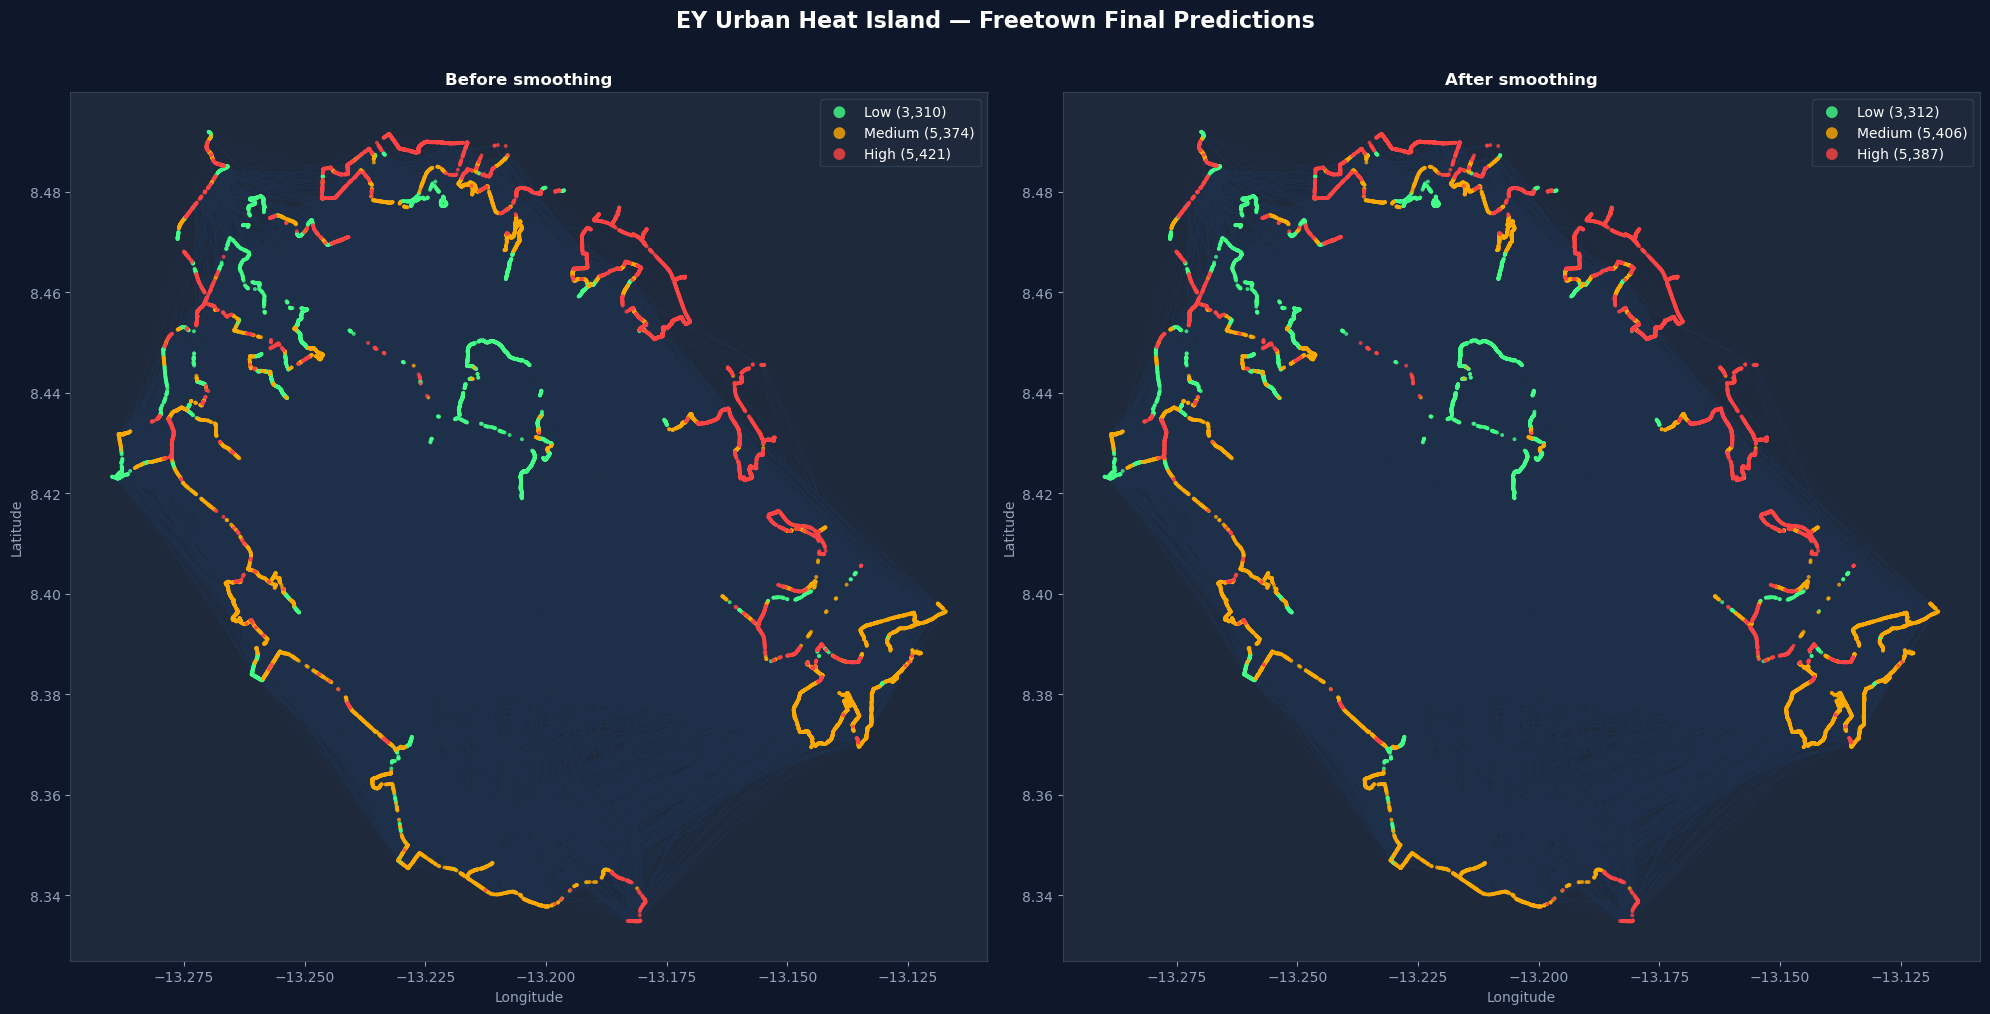

 Saved: final_freetown_predictions.png


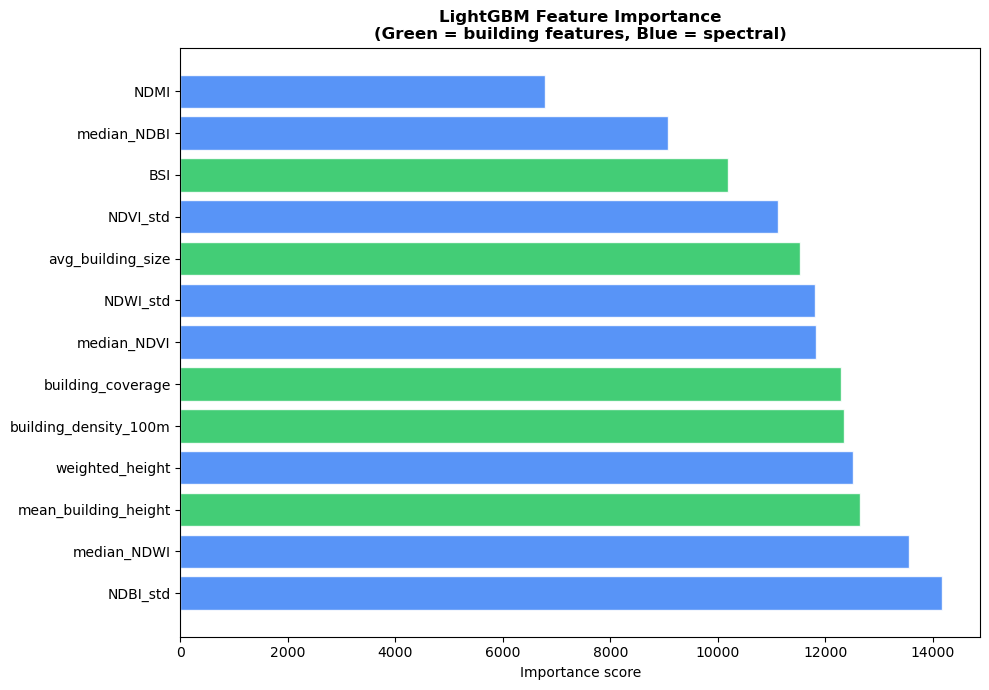


═══════════════════════════════════════════════════════
 ALL DONE
═══════════════════════════════════════════════════════
  what_changed_freetown_improved_submission.csv  ← submit this
  final_freetown_predictions.png    ← for presentation
  feature_importance.png            ← for report


In [ ]:
#  Presentation-quality map 
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.patch.set_facecolor('#0f172a')

COL = {'High': '#FF4444', 'Medium': '#FFAA00', 'Low': '#44FF88'}

for ax, col, title in [
    (axes[0], 'pred_raw',    'Before smoothing'),
    (axes[1], 'pred_smooth', 'After smoothing'),
]:
    ax.set_facecolor('#1e293b')
    ax.plot(sierra_r['Longitude'], sierra_r['Latitude'],
            color='#1e3a5f', linewidth=0.5, alpha=0.4)
    for cls in ['Low', 'Medium', 'High']:
        sub = sierra_r[sierra_r[col] == cls]
        ax.scatter(sub['Longitude'], sub['Latitude'],
                   c=COL[cls], s=8, alpha=0.8, label=f'{cls} ({len(sub):,})',
                   edgecolors='none', zorder=3)
    ax.set_title(title, fontsize=12, fontweight='bold', color='white')
    ax.set_xlabel('Longitude', color='#94a3b8')
    ax.set_ylabel('Latitude',  color='#94a3b8')
    ax.tick_params(colors='#94a3b8')
    for sp in ax.spines.values(): sp.set_color('#334155')
    ax.legend(markerscale=3, fontsize=10,
              facecolor='#1e293b', edgecolor='#334155', labelcolor='white')

plt.suptitle('EY Urban Heat Island — Freetown Final Predictions',
             fontsize=16, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.savefig('final_freetown_predictions.png', dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(' Saved: final_freetown_predictions.png')

#  Feature importance comparison 
fig, ax = plt.subplots(figsize=(10, 7))
lgbm_imp = lgbm.feature_importances_
idx = np.argsort(lgbm_imp)[::-1]
colors_fi = ['#22c55e' if 'building' in MODEL_FEATURES[i] or 'BSI' in MODEL_FEATURES[i]
             else '#3b82f6' for i in idx]
ax.barh([MODEL_FEATURES[i] for i in idx], [lgbm_imp[i] for i in idx],
        color=colors_fi, alpha=0.85, edgecolor='white')
ax.set_title('LightGBM Feature Importance\n(Green = building features, Blue = spectral)',
             fontweight='bold')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

#  Save submission
submission = sierra_combined[['Longitude', 'Latitude']].copy()
submission['UHI_Class'] = sierra_r['pred_smooth'].values
submission.to_csv('what_changed_freetown_improved_submission.csv', index=False)

print('\n' + '═'*55)
print(' ALL DONE')
print('═'*55)
print('  what_changed_freetown_improved_submission.csv  ← submit this')
print('  final_freetown_predictions.png    ← for presentation')
print('  feature_importance.png            ← for report')

---
##  Visualisation

###  Feature importance

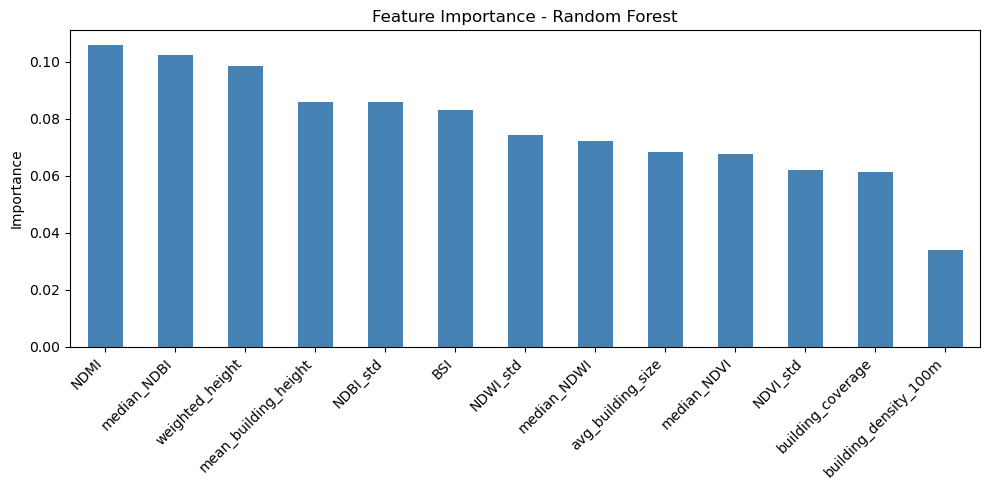


Top 8 features:
NDMI                    0.1057
median_NDBI             0.1022
weighted_height         0.0985
mean_building_height    0.0859
NDBI_std                0.0858
BSI                     0.0829
NDWI_std                0.0743
median_NDWI             0.0720


In [ ]:
importances = pd.Series(rf_model.feature_importances_, index=MODEL_FEATURES).sort_values(ascending=False)

plt.figure(figsize = (10, 5))
importances.plot(kind='bar', color = 'steelblue')
plt.title('Feature Importance - Random Forest')
plt.ylabel('Importance')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

print("\nTop 8 features:")
print(importances.head(8).round(4).to_string())

---
## Recommendations



### Which factor contributes the most to predicting urban heat islands
The most important factor is the built-up intensity of an area (captured by NDBI), which reflects how dense and developed a location is. In practical terms, places with more buildings, concrete, and roads tend to trap and generate more heat, making them hotter than less developed areas.

### What other practical solutions do you believe will reduce the presence of urban heat islands in the three cities of interest
Urban heat island (UHI) in Freetown is most intense in high-activity coastal zones such as the Freetown Port and Kissy Ferry Terminal, where dense built-up surfaces, traffic congestion, and limited airflow trap heat. Informal settlements like Kroo Bay, Susan’s Bay, and parts of Kissy worsen this effect due to widespread use of metal roofing that absorbs and re-radiates solar heat. Continuous human and vehicular activity further increase anthropogenic heat in these already compact urban areas (Macarthy, 2024).
In the short term, Freetown should introduce structured traffic management around the port and ferry terminal by creating designated holding zones to reduce congestion spillovers. Strict no-idling rules should be enforced to limit unnecessary vehicle heat emissions. 
Freight operations should be rescheduled to early morning and evening hours to avoid peak daytime heat buildup. Port entry scheduling and monitoring should be used to reduce long vehicle queues. These measures can be implemented quickly through municipal regulation and enforcement at low cost.
Santiago should enforce mandatory cool roof standards which require high solar reflectance and thermal emittance for roofs in new and renovated buildings. These requirements should be implemented through clear Solar Reflectance Index (SRI) thresholds. Priority should be given to high-UHI areas such as Santiago Centro, Quinta Normal, Maipú, and Puente Alto, supported by compliance monitoring and retrofit incentives. 


### What additional data do you feel would add value to predicting urban heat islands
Population density would improve the model since highly populated areas tend to generate and retain more heat due to human activity and infrastructure. Data indicating whether locations fall within towns or city centers would also be valuable, as these areas, especially markets, are typically hotter than surrounding regions. Additionally, information on industrial zones would help, since areas with factories and heavy operations contribute extra heat through energy use and emissions.

---
# Key Components of the analysis

The analysis combines remote sensing data and machine learning to predict urban heat island (UHI) intensity across multiple cities. The input to the models consists of 13 features derived from Sentinel-2 satellite imagery, including indices such as NDVI, NDBI, and BSI, along with building-related features like density and height. These features capture environmental and urban characteristics that influence temperature patterns at each GPS point. Before modelling, a StandardScaler is applied to normalize the data so that differences across cities do not distort the learning process.

A key component of the approach is the Residual MLP, a neural network designed to learn patterns in layers. The first block captures simple relationships such as low vegetation or high built-up areas, while later blocks learn more complex interactions between features. Skip connections are used to preserve the original input information throughout the network, ensuring important signals are not lost. The model outputs probabilities for three classes, Low, Medium, and High UHI, and selects the highest as the final prediction.

In addition to the neural network, three tree-based models are used: Random Forest, LightGBM, and XGBoost. Random Forest builds many independent decision trees and aggregates their votes, making it stable and resistant to noise. LightGBM and XGBoost follow a boosting approach, where each new tree improves upon the errors of the previous ones, leading to strong predictive performance. XGBoost also reduces overfitting through regularization, which helps when applying the model across different cities.

The models are combined using a soft voting ensemble, where each model contributes probability scores instead of just final predictions. This allows the system to balance the strengths of each approach and reduce individual model bias. To improve performance in Freetown, the model is first trained on labelled data from Chile and Brazil, then refined using pseudo-labelling on high confidence predictions. Finally, spatial smoothing is applied to ensure geographic consistency by correcting unrealistic isolated predictions. Together, these components create a robust and adaptable system for predicting UHI intensity across diverse urban environments.


---
# Conclusion

In conclusion, this analysis demonstrates that urban heat island intensity can be effectively predicted using a combination of satellite-derived features and machine learning models. By leveraging Sentinel-2 spectral data and extracting meaningful indices, the models were able to capture key environmental and urban patterns that influence temperature distribution. The results highlight that built-up intensity plays a major role in driving urban heat, reinforcing the importance of urban design in managing temperature risks. The use of multiple models and an ensemble approach improved prediction reliability by combining different learning strengths.
The ability of the models to generalize from Santiago and Rio de Janeiro to Freetown shows that transferable patterns of urban heat can be learned despite geographic differences. Techniques such as pseudo-labelling and spatial smoothing further enhanced model performance and ensured more realistic predictions. Beyond predictive performance, the analysis also provides practical insights for urban planning, particularly in managing high-density and high-activity areas.
Overall, this study confirms that data-driven approaches can support better understanding and mitigation of urban heat islands. It also highlights the importance of integrating additional human and environmental data to further improve predictions. These findings can help inform more effective, scalable solutions for reducing heat exposure in rapidly growing urban environments .


---
# Feeback on the Challenge

### What We Found Most Valuable
The most valuable aspect of the challenge was the requirement to generalise models across geographically and climatically distinct cities, rather than relying on within-city validation. Training on Santiago and Rio de Janeiro while predicting for Sierra Leone forced us to critically evaluate which predictors capture transferable urban heat island dynamics versus those that are location-specific artefacts. This strengthened our understanding of domain shift, particularly in remote sensing applications where land cover, urban form, and climate vary significantly. A key benefit was also working directly with geospatial and satellite-derived data to address a real-world problem, which improved our ability to translate spatial datasets into actionable environmental insights. The challenge reinforced both robust modelling practices and the value of applying analytics to solve real-life environmental challenges.

### What We Would Change

One improvement would be to include intermediate validation datasets from additional cities representing different climatic zones and urban typologies. This would allow teams to better quantify model generalisation performance before final testing on the target city. We would also benefit from clearer guidance on uncertainty estimation, as predicting UHI in a new geographic context inherently involves high uncertainty that should be explicitly modelled. Finally, including basic weather observations (wind speed, wind direction, and cloud cover) for each data collection day would help account for meteorological influences on temperature variability that the current dataset cannot capture. This would not simplify the challenge but would make it more scientifically robust and better reflect real-world urban climate modelling conditions.

---
# References

Macarthy, J. M. (2024). Freetown city report. African Cities Research Consortium.
https://www.african-cities.org/wp-content/uploads/2024/06/ACRC_Working-Paper-16_June-2024.pdf

California Energy Commission. (2025). Building Energy Efficiency Standards (Title 24, Part 6).
https://www.energy.ca.gov/programs-and-topics/programs/building-energy-efficiency-standards

Cool Roof Rating Council. (n.d.). Los Angeles Green Building Code: Cool roof requirements.
https://coolroofs.org/resources/los-angeles-green-building-code
